# AR segmentation: error bars, calibration and the label floor

This notebook completes the six-step programme in `NOTEBOOKS_EXPLAINED.md` → *A concrete
order of work*. It assumes you have already run **0_dataset_dataloader_ar.ipynb**,
**1_baseline_ar.ipynb** and **2_finetune_ar.ipynb**.

| Step | What it produces | Needs training? |
|---|---|---|
| 1 | A sample and epoch budget that makes the numbers mean something | sets up the rest |
| 2 | Bootstrap confidence intervals on every reported score | no |
| 3 | A reliability diagram and a fitted calibration | no |
| 4 | Multi-level confidence contours on the calibrated map | no |
| 5 | An ensemble of adapter seeds: mean prediction and disagreement map | **yes**, N runs |
| 6 | The label floor: how much the answer key itself moves | no |

**The single most important idea here.** Notebooks 1 and 2 report one number per run.
One number cannot tell you whether a gap between two models is real. Steps 2–6 replace
each number with an interval, and then compare those intervals against how much the
*answer key itself* wobbles when you nudge a threshold nobody can justify to three digits.

### The one idea

Suppose the model scores 0.72 and the baseline scores 0.68. Is the model better? You cannot
tell from those two numbers, because four different things could be hiding inside the gap:

| Question | What it is about | Answered in |
|---|---|---|
| Would I get the same number with different images? | Sampling: the score comes from a handful of images | Step 2 |
| How sure is the model about each pixel, and is that confidence honest? | The model's own hesitation, and whether "80 %" means 80 % | Steps 3 and 4 |
| Would I get the same number if the model were trained again? | Randomness in training | Step 5 |
| Is the answer key precise enough to be measured against at this resolution? | The outlines come from a rule with arbitrary settings | Step 6 |

The notebook replaces the single number with an **interval** for each, then asks whether the
gap between two models is bigger than all of them. Only then is "better" a defensible word.

### Where this sits in the pipeline

```mermaid
flowchart LR
    A[SDO images<br/>13 channels, 12-min] --> P[Pair by exact<br/>timestamp]
    M[HMI magnetogram] --> R[Marking rule<br/>±50 G · 100 px · grow 10 px · needs a PIL] --> K[Answer key<br/>hourly outlines] --> P
    P --> N1[Notebook 1<br/>14-number baseline]
    P --> N2[Notebook 2<br/>Surya + adapters]
    N1 --> S[One score each]
    N2 --> S
    S --> N3[This notebook<br/>intervals · calibration · contours · ensemble · label floor]
```

*Diagrams are Mermaid; JupyterLab 4.1+ renders them. Plain `nbconvert` HTML shows the source.*

### Three companion documents

| document | what it is for |
|---|---|
| `NOTEBOOKS_EXPLAINED.md` | the three notebooks before this one, and the labelling rule, in plain language |
| `ERRORS_NOTEBOOK_EXPLAINED.md` | this notebook, section by section |
| `GROUND_TRUTH_EXPLAINED.md` | where the answer key comes from, exactly how it is made, and how faithfully it reproduces |

Most of the text between the cells below is drawn from those three, so the notebook reads on
its own.


## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device
you put here is the one assigned to your team and your machine.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

### Imports, and one setting that has to come first

`CUBLAS_WORKSPACE_CONFIG` is read exactly once, when the GPU maths library starts up. Setting
it after `torch` has been imported does nothing at all — it does not warn, it simply has no
effect. That is why it sits above the imports here and in every other notebook in this app.
**If you have already imported `torch` in this kernel session, restart the kernel now.**

`sys.path.append("../../")` puts the repository root on the import path, which is what makes
`workshop_infrastructure` and `downstream_apps` importable from inside this folder.

The only line worth reading in the output is `DEVICE`. Everything below runs on whatever it
prints, and on CPU the Surya path will be unusably slow — switch `MODEL_KIND` to `"baseline"`
in that case.

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Gives the notebook access to workshop_infrastructure/ and downstream_apps/.
sys.path.append("../../")

from workshop_infrastructure.utils import build_scalers

torch.set_float32_matmul_precision("medium")
warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


---
# Step 1 — Raise the sample cap and the epoch count

`configs/config_script.yaml` ships with `max_samples: 10` and a handful of epochs. That is a
plumbing test: it proves the code runs, and it tells you nothing about the Sun. Ten images
give an overlap score whose confidence interval is wider than the entire range the score can
take.

Two presets below. **`smoke` exists so you can run this notebook end to end in a few minutes
and see every figure appear.** Its numbers are meaningless by construction. Switch to `real`
once you have a GPU and some hours, and re-read every conclusion.

Budget guidance for `real`:

- Each unique timestamp downloads roughly 1 GB the first time it is touched, then caches.
- One Surya training step at 4096x4096 with batch size 1 needs a large GPU.
- Step 5 multiplies the training cost by `n_seeds`. Everything else is inference only.

**A note on sizing for a container.** `free` and `nproc` report the whole node, not the pod
you are running in. The pod's real limits live in `/sys/fs/cgroup/` (`memory.max`,
`cpu.max`), and a process that exceeds the memory one is not slowed down — the whole pod is
killed and restarted, wiping `/tmp` with it. The budget cell reads those limits and derives
`NUM_WORKERS` from measured per-worker costs, printing the arithmetic so you can check it.

### The presets

| preset | images | passes over the data | models trained | what it is for |
|---|---|---|---|---|
| `smoke` | 8 | 2 | 2 | Minutes. Proves the code runs. **Every number it prints is noise.** |
| `medium` | 60 | 10 | 2 | Hours. Past the 30-image mark where an interval starts to mean something; long enough to see whether training is heading somewhere. |
| `real` | 400 | 20 | 5 | Numbers you could report. ~800 unique timesteps to download. |

Start with `smoke` to see every figure appear, then `medium` to learn whether the setup is
sound, and only then `real`. Skipping straight to `real` risks spending a day training a model
that was going to fail anyway — see the worked example at the end.

### The five knobs in the next cell

| knob | default | alternatives | one-line meaning |
|---|---|---|---|
| `BUDGET` | `"medium"` | `"smoke"`, `"real"` | how big a run |
| `MODEL_KIND` | `"surya"` | `"baseline"` | foundation model + adapters, or the 14-number pixel model (runs anywhere) |
| `SAMPLE_SELECTION` | `"window"` | `"stratified"`, `"head"` | which years the images come from |
| `POS_WEIGHT_MODE` | `"sqrt"` | `"full"`, `"off"`, a number | how hard to up-weight the rare active-region pixels |
| `LOSS` | `"bce+dice"` | `"bce"` | whether training also optimises overlap directly |
| `NUM_WORKERS` | derived, cap 4 | edit the cap | data-loading processes, sized from the container's real limits |

Measured wall time on one L40S GPU: `smoke` ≈ 8 min including setup; `medium` ≈ 4.9 s per
training step, roughly 2.5 h end to end.


In [3]:
BUDGET = "real"        # "smoke" -> runs in minutes, numbers are meaningless
                        # "real"  -> numbers you can actually report

MODEL_KIND = "surya"    # "surya"    -> Surya backbone + LoRA adapters (needs a big GPU)
                        # "baseline" -> the 14-parameter pixel model (runs anywhere, fast)

PRESETS = {
    # Runs in minutes; every number it produces is noise. Proves the code works.
    "smoke":  dict(max_samples=8,   max_epochs=2,  n_seeds=2, n_boot=1000, contour_images=2),
    # The intermediate step. Past the 30-image mark where a bootstrap interval starts
    # carrying information, and long enough to see whether recall stabilises or keeps
    # sliding -- the open question after smoke. Hours, not days.
    "medium": dict(max_samples=60,  max_epochs=10, n_seeds=2, n_boot=2000, contour_images=3),
    # Numbers you could report. ~800 unique timesteps to download.
    "real":   dict(max_samples=400, max_epochs=20, n_seeds=5, n_boot=2000, contour_images=4),
}
P = PRESETS[BUDGET]

# --- Fixes for the collapse seen in the first run of this notebook -------------
# That run drove val_loss down while IoU fell 155x: precision -> 1.0, recall -> 0.
# The model had learned to predict nothing, which is close to optimal for plain
# BCE when AR pixels are ~0.1% of the disk. Three knobs address it.

# (a) WHICH IMAGES. AR coverage swings ~78x over the solar cycle: 0.023% in 2019,
#     1.80% in 2014. The dataset otherwise takes the FIRST max_samples timestamps
#     chronologically, i.e. mid-January 2011, among the quietest in the archive.
SAMPLE_SELECTION = "window-stratified"           # "window" | "window-stratified" | "stratified" | "head"
SAMPLE_WINDOW    = ("2013-01-01", "2015-12-31")  # solar maximum of cycle 24

# (b) CLASS IMBALANCE. pos_weight multiplies AR pixels in the BCE.
#     "full" = (1-p)/p from measured coverage; "sqrt" is gentler and more stable;
#     a float overrides; "off" reproduces the collapse.
POS_WEIGHT_MODE  = "sqrt"                        # "sqrt" | "full" | "off" | float

# (c) LOSS. BCE is not the quantity being scored. A soft-Dice term optimises
#     overlap directly, which is what IoU and Dice measure.
LOSS             = "bce+dice"                    # "bce" | "bce+dice"

# (d) EARLY STOPPING. Seed 0 of the first medium run reached its best val_loss at
#     epoch 1 of 10 and spent the other eight overfitting 60 images. Stop after this
#     many epochs without improvement; None trains the full max_epochs.
EARLY_STOP_PATIENCE = 3

# --- Throughput -----------------------------------------------------------------
# The smoke run left the GPU at 0% while the CPU sat at 48%: two loader processes
# could not decode 13x4096x4096 stacks fast enough to keep it fed. The fix is more
# workers -- but sized against the limits that actually apply. Inside a container,
# `free` and `nproc` report the NODE (here 124 GB, 16 cores). The first medium run
# was sized from those, used num_workers=10, and the pod was killed at its real
# cgroup limit (60 GiB, 7 cores), taking /tmp and the run log with it.
import os
import psutil


def cgroup_limits():
    """(cpu_cores, mem_gib) available to this pod; node values where no limit is set."""
    cpus = float(os.cpu_count() or 1)
    mem = psutil.virtual_memory().total / 2**30
    try:
        quota, period = open("/sys/fs/cgroup/cpu.max").read().split()
        if quota != "max":
            cpus = min(cpus, int(quota) / int(period))
    except OSError:
        pass
    try:
        lim = open("/sys/fs/cgroup/memory.max").read().strip()
        if lim != "max":
            mem = min(mem, int(lim) / 2**30)
    except OSError:
        pass
    return cpus, mem


CPU_LIMIT, MEM_LIMIT_GB = cgroup_limits()

# Measured during training on this data, from cgroup memory.stat -- not guessed.
# What can kill the pod is UNRECLAIMABLE memory: anon + shmem. Per DataLoader
# worker that is ~0.4 GB anon plus its prefetch_factor=2 queue of 13x4096x4096
# float32 samples in shared memory (measured 1.6 GB); the training process is
# ~9 GB anon. build_helio_dataloaders() sets persistent_workers=True, so the
# train and val loaders' workers all exist at once: count both.
#
# The kernel ALSO charges this cgroup for the page cache of every .nc file the
# workers read (~0.56 GB each), so memory.current climbs to the limit within the
# first epoch and stays there. That is reclaimable and harmless: observed 6,907
# successful reclaims at the limit with zero OOMs. Do not size against
# memory.current; size against anon+shmem.
_PER_WORKER_GB = 0.4 + 1.6
_MAIN_GB = 9.0
_HEADROOM = 0.60          # unreclaimable may use 60% of the limit; validation, the
                          # collect() maps and step 6 spike above steady state.
                          # Measured (medium, 4 workers): ~25 GB steady, 35 GB peak at the
                          # seed boundary (checkpoint save + building the next model).
_by_mem = int((MEM_LIMIT_GB * _HEADROOM - _MAIN_GB) / (2 * _PER_WORKER_GB))
_by_cpu = int(CPU_LIMIT) - 1   # only one loader is busy at a time; keep a core for training
# Cap of 4: that already drove an L40S to 100% utilisation on this data. Raise it
# only if the watchdog shows the GPU idle -- more workers past saturation add
# memory, not throughput.
NUM_WORKERS = max(1, min(_by_mem, _by_cpu, 4))
PREFETCH_THREADS = 16          # threads, network-bound: not subject to the core count

_est = _MAIN_GB + 2 * NUM_WORKERS * _PER_WORKER_GB
print(f"pod limits     : {CPU_LIMIT:.0f} cores, {MEM_LIMIT_GB:.0f} GB "
      f"(node reports {os.cpu_count()} cores, {psutil.virtual_memory().total/2**30:.0f} GB)")
print(f"NUM_WORKERS    : {NUM_WORKERS}   (memory allows {_by_mem}, cpu allows {_by_cpu}, cap 4)")
print(f"unreclaimable  : ~{_est:.0f} GB anon+shmem at steady state, of the {MEM_LIMIT_GB:.0f} GB limit")
print( "               : page cache from the .nc reads will fill the rest; the kernel reclaims it")
if _est > 0.8 * MEM_LIMIT_GB:
    print("*** estimate is within 20% of the limit; lower NUM_WORKERS or the pod may be killed ***")

print(f"budget={BUDGET}  model={MODEL_KIND}")
for k, v in P.items():
    print(f"  {k:15s} {v}")
if BUDGET == "smoke":
    print("\n*** SMOKE BUDGET: every number below is noise. Switch to 'real' to report anything. ***")

budget=smoke  model=surya
  max_samples     8
  max_epochs      2
  n_seeds         2
  n_boot          1000
  contour_images  2

*** SMOKE BUDGET: every number below is noise. Switch to 'real' to report anything. ***


### Load the configuration, then apply the new budget

`load_ar_config()` parses the same YAML that Notebooks 1 and 2 use, so nothing here can quietly
drift away from them. The two assignments that follow are **Step 1 in action**: they override
the sample cap and the epoch count in memory.

Overriding here rather than editing the YAML keeps the checked-in config honest about what it
actually ships with, and it means flipping `BUDGET` above changes the run without touching a
file the other notebooks read.

The assertion at the bottom guards Step 6. That step re-derives the answer key from the
magnetogram, and block-averaging the inputs cannot be undone — so the notebook refuses to run
at reduced resolution rather than silently producing a meaningless label floor.

| model | learning rate used | why |
|---|---|---|
| `baseline` | `cfg.learning_rate` = 1e-3 | 14 parameters; the config's own default |
| `surya` | **1e-4** | the config's comment says "use ~1e-4 for Surya"; 1e-3 on a 3 M-parameter adapter set was one of the three causes of the collapse described at the end |


In [4]:
from downstream_apps.ar_segmentation.configs import load_ar_config

config_path = os.environ.get("AR_CONFIG", "./configs/config_script.yaml")
cfg = load_ar_config(config_path)

# Step 1 applied. These are plain dataclass fields, so overriding here is equivalent to
# editing the YAML -- but it keeps the checked-in config honest about its own defaults.
cfg.data.max_samples = P["max_samples"]
cfg.max_epochs = P["max_epochs"]

# The YAML says: "learning_rate: 0.001  # fine for the 14-parameter baseline;
# use ~1e-4 for Surya". Honour that instead of passing one rate to both models:
# 1e-3 on a 3M-parameter adapter set is a reliable way to collapse the head.
LEARNING_RATE = 1e-4 if MODEL_KIND == "surya" else cfg.learning_rate

print(f"job          : {cfg.job_id}")
print(f"max_samples  : {cfg.data.max_samples}")
print(f"max_epochs   : {cfg.max_epochs}")
print(f"batch_size   : {cfg.batch_size}")
print(f"learning_rate: {LEARNING_RATE:g}   (config default {cfg.learning_rate:g})")
print(f"mask key     : {cfg.data.ar_mask_key}")
print(f"threshold    : {cfg.data.ar_threshold}")

assert cfg.data.ar_pooling == 1, (
    "This notebook assumes native 4096x4096 resolution: step 6 re-derives the answer key "
    "from the magnetogram, and pooling is not invertible. Set data.ar_pooling: 1."
)

job          : ar_segmentation_baseline
max_samples  : 8
max_epochs   : 2
batch_size   : 1
mask key     : union_with_intersect
threshold    : 0.5


### Fetch the weights and the normalization statistics

`ensure_assets()` downloads only what is missing, so re-running this costs nothing. Surya needs
the pretrained checkpoint; the 14-parameter baseline does not, which is why the list depends on
`MODEL_KIND`.

The scalers are the per-channel statistics that put every input channel on a comparable numeric
scale. They matter **twice** in this notebook: once for feeding the model, and again in Step 6,
where they are run *backwards* to recover the magnetic field in physical units (gauss). That
second use is why this cell cannot be skipped even if you are only interested in the label floor.

### The three "spaces" the data lives in

The pipeline is signum-log **then** z-score, so there are two different "inverse" operations,
and Step 6 depends on using the right one:

| space | what the numbers are | how you get there |
|---|---|---|
| **normalised** | what the model sees: `sign(x)·log(1+|x|)`, then z-scored per channel | the dataset's `__getitem__` |
| **signum-log** | z-score undone, log compression kept | `scaler.inverse_transform()` — what the baseline model consumes |
| **physical** | DN for the ultraviolet channels, **gauss** for the magnetic ones | `dataset.inverse_transform_data()` — what Step 6 uses to re-run the labelling rule |


In [5]:
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers", "weights"] if MODEL_KIND == "surya" else ["scalers"])
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

Loaded scalers for 13 channels.


### Build the data loaders

`build_helio_dataloaders()` fills in roughly twenty dataset arguments straight from the config;
only the task-specific ones are passed by hand. This is the identical call Notebooks 1 and 2
make, so the images and outlines here are exactly the ones those notebooks trained and scored
on — which is what makes any comparison with them legitimate.

The validation loader is not shuffled and uses `phase="val"`, which switches off the random
channel masking applied during training.

**Read the validation count in the output.** Everything in Steps 2 through 5 is computed on that
set. If it is small, every interval below will be wide — and the notebook warns under 30 images,
which is roughly where a bootstrap interval stops carrying information.

### How images and outlines are paired

| rule | consequence |
|---|---|
| Outlines are **hourly**; images are every **12 minutes** | only on-the-hour images pair — about 1 in 5 |
| Pairing is an **exact timestamp match** | no interpolation, no nearest-neighbour |
| Only catalogue rows with `present == 1` are used | hours with no valid magnetogram are dropped |
| Both maps are loaded as `> 0` | the two keys are stored differently (0/255 and 0/1); this makes both a float 0/1 image |
| Train vs validation is decided by the **image** index, not the outline catalogues | the four outline CSVs are loaded only as a lookup table; the image index's validation set is mid-to-late January each year |
| No vertical flips | the base loader would flip the image but not the outline |


In [6]:
from downstream_apps.ar_segmentation.datasets.ar_dataset import ARSegmentationDataset
from workshop_infrastructure.datasets.builders import build_helio_dataloaders

train_loader, val_loader = build_helio_dataloaders(
    cfg,
    ARSegmentationDataset,
    scalers=scalers,
    num_workers=NUM_WORKERS,
    return_surya_stack=True,
    max_number_of_samples=None,   # capped by select_timestamps() below
    ds_mask_dir=cfg.data.ar_mask_dir,
    ds_mask_splits=cfg.data.ar_mask_splits,
    ds_mask_key=cfg.data.ar_mask_key,
    pooling=cfg.data.ar_pooling,
)
print(f"train: {len(train_loader.dataset)} | val: {len(val_loader.dataset)} matched timestamps (before selection)")


train: 8 samples | val: 8 samples

*** 8 validation images is far too few for a confidence interval. ***
*** Step 2 will show you exactly how wide the resulting interval is.        ***


### Choosing *which* images, not just how many

The dataset pairs every on-the-hour image with an outline and sorts them chronologically, so
capping with `max_samples` takes the **earliest** timestamps -- mid-January 2011, near the
bottom of the solar cycle.

Measured from the outlines shipped with the dataset:

| year | AR coverage | imbalance |
|---|---|---|
| 2010 | 0.19 % | 516:1 |
| 2013 | 1.37 % | 73:1 |
| **2014** | **1.80 %** | **55:1** |
| 2016 | 0.47 % | 215:1 |
| 2019 | 0.023 % | 4285:1 |

A 78-fold swing. Training on January 2011 gives roughly one AR pixel per thousand; training on
2014 gives one in fifty-five. Same model, same code, eighteen times more signal per image.

`"window"` restricts **both** train and validation to the same date range. That is a stated
restriction of scope -- "this experiment is about solar maximum" -- and it is honest. What
would *not* be honest is ranking validation images by AR coverage and keeping the richest:
that inflates every score by choosing an easier test set. The helper deliberately offers no
such option.

`"window-stratified"` keeps the window but spreads the sample evenly across it — at 400 images,
plain `"window"` would take 17 consecutive days of March 2013, the same regions rotating across
the disk, and position matters (per-image IoU tracks distance from disk centre at r = −0.94).

`"stratified"` spreads the sample evenly across the whole archive instead, which is what you
want if the model has to work at any point in the cycle.

### Two caveats on the date window

- **Solar cycle.** Coverage peaks around 2013–2015 (cycle 24 maximum) and falls to almost
  nothing by 2019. A model trained only on the window is a *solar-maximum* model; use
  `"stratified"` if it must work across the cycle.
- **2010 is unusual.** The 5,291 masks from May–December 2010 were absent from the preprint
  version of the dataset and added at publication, and the rule does not reproduce them from
  the magnetograms served here (Step 6 shows this). Avoid 2010 for the label floor.


In [ ]:
def select_timestamps(ds, n, selection=SAMPLE_SELECTION, window=SAMPLE_WINDOW):
    """Restrict a dataset to n timestamps chosen by `selection`, in place.

    Safe because both halves of a sample resolve from the same timestamp:
    HelioNetCDFDataset._get_index_data() reads self.valid_indices[idx] for the image,
    and ARSegmentationDataset.__getitem__ reads mask_paths[that timestamp] for the
    outline. Subsetting the list therefore cannot desynchronise the pair.
    """
    ts = pd.DatetimeIndex(ds.valid_indices)
    if selection == "window":
        keep = ts[(ts >= pd.Timestamp(window[0])) & (ts <= pd.Timestamp(window[1]))]
        if len(keep) == 0:
            raise ValueError(f"No timestamps inside {window}. Widen SAMPLE_WINDOW.")
    elif selection == "window-stratified":
        # Restrict to the window, then spread evenly across it. "window" alone takes
        # the first n stamps, which at n=400 is 17 consecutive days of the same regions
        # rotating across the disk; this keeps the solar-maximum scope but samples all
        # three years.
        inwin = ts[(ts >= pd.Timestamp(window[0])) & (ts <= pd.Timestamp(window[1]))]
        if len(inwin) == 0:
            raise ValueError(f"No timestamps inside {window}. Widen SAMPLE_WINDOW.")
        keep = inwin[np.linspace(0, len(inwin) - 1, min(n, len(inwin))).astype(int)]
    elif selection == "stratified":
        keep = ts[np.linspace(0, len(ts) - 1, min(n, len(ts))).astype(int)]
    elif selection == "head":
        keep = ts
    else:
        raise ValueError(f"unknown selection {selection!r}")

    keep = keep[:n]
    ds.valid_indices = [pd.Timestamp(t) for t in keep]
    ds.adjusted_length = len(ds.valid_indices)
    return ds


for name, ds in [("train", train_loader.dataset), ("val", val_loader.dataset)]:
    before = len(ds.valid_indices)
    select_timestamps(ds, P["max_samples"])
    span = (f"{ds.valid_indices[0].date()} .. {ds.valid_indices[-1].date()}"
            if ds.valid_indices else "EMPTY")
    print(f"{name:5s}: {before} -> {len(ds.valid_indices)} samples   {span}")

N_VAL = len(val_loader.dataset)
if N_VAL < 30:
    print(f"\n*** {N_VAL} validation images is far too few for a confidence interval. ***")
    print("*** Step 2 will show you exactly how wide the resulting interval is.        ***")

### Measuring the imbalance, then weighting for it

The previous run used `ar_pos_weight: null`. With AR pixels at 0.1 % of the disk, plain binary
cross-entropy has a degenerate optimum: answer "background" everywhere and the loss is already
small. That is exactly what happened -- recall fell to 0.000035 while the loss kept improving.

`pos_weight` multiplies the contribution of AR pixels, restoring the balance. This cell
measures the true coverage from the outlines actually selected above, rather than trusting a
figure in a comment, and derives the weight from it.

- **`full`** = (1 - p) / p balances the classes exactly. It maximises recall and usually
  over-predicts, which shows up as low precision.
- **`sqrt`** is the square root of that -- the usual compromise, and the default here.
- Watch **precision and recall together** in Step 2. Collapse looks like recall -> 0;
  over-correction looks like precision -> 0. Neither is progress.

### What the weight comes to under each selection

Measured on this data. `full` = (1 − p)/p; `sqrt` is its square root.

| selection | images from | AR coverage *p* | imbalance | `sqrt` weight | `full` weight |
|---|---|---|---|---|---|
| `head` | Jan 2011 | 0.101 % | 987 : 1 | 31.4 | 987 |
| `window` | 2013–2015 | 0.9–1.6 % | 62–113 : 1 | 7.9–10.6 | 62–113 |
| `stratified` | 2011–2024 | 0.86 % | 115 : 1 | 10.7 | 115 |

### How to read the training metrics that follow

Watch **precision and recall together**, not the loss. The pair is the diagnostic:

| signature | precision | recall | meaning | fix |
|---|---|---|---|---|
| **Collapse** | → 1.0 | → 0 | predicts nothing; *the loss keeps improving while this happens* | raise `pos_weight`; check the sample selection |
| **Over-correction** | → 0 | → 1.0 | flags everything | lower `pos_weight` (`"full"` → `"sqrt"` → a number) |
| **Healthy** | both away from 0 and 1 | | real predictions, wrong in both directions, improving | keep going |

The second training-loss term (`dice`) should also **move**. If it stays near 1.0 while the
first term falls, nothing is being localised yet.


In [ ]:
import math
import h5py


def measure_pos_fraction(ds, max_files=40):
    """Mean fraction of pixels marked active region, read straight from the outlines."""
    stamps = ds.valid_indices[:max_files]
    fracs = []
    for t in stamps:
        with h5py.File(ds.mask_paths[t], "r") as f:
            fracs.append(float((f[ds.mask_key][...] > 0).mean()))
    return float(np.mean(fracs)) if fracs else 0.0


POS_FRAC = measure_pos_fraction(train_loader.dataset)
_full = (1.0 - POS_FRAC) / POS_FRAC if POS_FRAC > 0 else 1.0

if POS_WEIGHT_MODE == "off":
    POS_WEIGHT = None
elif POS_WEIGHT_MODE == "full":
    POS_WEIGHT = _full
elif POS_WEIGHT_MODE == "sqrt":
    POS_WEIGHT = math.sqrt(_full)
else:
    POS_WEIGHT = float(POS_WEIGHT_MODE)

print(f"measured AR coverage : {POS_FRAC:.5f}  ({POS_FRAC:.3%} of the disk)")
print(f"imbalance            : {_full:.0f} background pixels per AR pixel")
print(f"pos_weight ({POS_WEIGHT_MODE:>4s})    : "
      f"{POS_WEIGHT if POS_WEIGHT is None else round(POS_WEIGHT, 2)}")
print(f"config value (unused): {cfg.data.ar_pos_weight}")
if POS_WEIGHT is None:
    print("\n*** pos_weight is off. Expect the model to collapse to all-background. ***")

### Warming the cache in parallel

Files are otherwise fetched **lazily**: the loader asks for a timestep, training stops, one
file downloads, training resumes. The `s3_boto3_max_concurrency` setting parallelises the parts
of a *single* file, but the files themselves arrive one after another, so every cache miss is a
stall.

This cell downloads everything the run will need up front, many files at once. S3 transfers are
network-bound rather than CPU-bound, so more threads than cores is fine.

It reuses the dataset's own `_s3_cache_path()` and `_download_s3_object()` rather than
reimplementing either. That matters twice over: the cache filename is a hash of the bucket and
key, so a hand-rolled name would simply be ignored and every file re-fetched; and the download
writes to a process-unique `.partial` file before an atomic rename, which is what makes
concurrent writers safe.

Already-cached files are skipped, so re-running costs nothing.

**Dask would also work here, but is not needed.** This is a flat list of independent downloads,
which a thread pool covers in a few lines. Dask earns its complexity on real task graphs or
when spreading work across several machines -- neither applies to pulling files onto one box.
It would not help the training loop at all: that belongs to the PyTorch DataLoader, and extra
Dask workers would only contend for the handful of cores the pod is actually allotted.

```
lazy (default)      [dl][train][dl][train][dl][train][dl][train] ...   GPU idle at every [dl]
prefetch (this cell) [dl dl dl dl dl dl dl dl][train][train][train][train] ...
                      16 at a time, once
```

Measured on this machine: 104 files (61 GB) in about 19 minutes, roughly 55 MB/s sustained.
For the `real` budget that makes the download a couple of hours, not days; after that,
training throughput is the only cost.


In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed


def prefetch_s3(ds, threads=PREFETCH_THREADS, label=""):
    """Download every object `ds` will read, in parallel. Returns (fetched, skipped)."""
    if getattr(ds, "s3_mode", None) != "download":
        print(f"{label}: s3_mode={getattr(ds, 's3_mode', None)!r}, nothing to prefetch")
        return 0, 0

    # time_delta_input_minutes is [0] for this task, so the reference timestamp is the
    # only frame read per sample. A task with several input frames would need to expand
    # each timestamp by its offsets here.
    uris = [str(ds.index.loc[t, "path"]) for t in ds.valid_indices]
    todo = [u for u in dict.fromkeys(uris)
            if u.startswith("s3://") and not os.path.exists(ds._s3_cache_path(u))]
    skipped = len(set(uris)) - len(todo)
    if not todo:
        print(f"{label}: all {skipped} files already cached")
        return 0, skipped

    print(f"{label}: {len(todo)} to fetch, {skipped} cached -- {threads} at a time")
    done, failed = 0, []

    def grab(uri):
        dest = ds._s3_cache_path(uri)
        tmp = f"{dest}.prefetch.{os.getpid()}.partial"
        try:
            ds._download_s3_object(uri, tmp)
            os.replace(tmp, dest)          # atomic: a racing loader either wins or loses
        except BaseException:
            if os.path.exists(tmp):
                os.remove(tmp)
            raise

    with ThreadPoolExecutor(max_workers=threads) as pool:
        futures = {pool.submit(grab, u): u for u in todo}
        for fut in as_completed(futures):
            try:
                fut.result()
                done += 1
                if done % 25 == 0 or done == len(todo):
                    print(f"  {done}/{len(todo)}")
            except Exception as exc:
                failed.append((futures[fut], repr(exc)[:120]))

    if failed:
        print(f"\n*** {len(failed)} download(s) failed; training will retry them lazily ***")
        for u, e in failed[:5]:
            print(f"    {u}: {e}")
    return done, skipped


import time
_t0 = time.time()
for _label, _ds in [("train", train_loader.dataset), ("val", val_loader.dataset)]:
    prefetch_s3(_ds, label=_label)
print(f"\nprefetch took {time.time() - _t0:.0f}s")

---
## Model factory

One function builds whichever model `MODEL_KIND` selects; another trains it under a given seed.
Everything downstream operates on the returned object, so the rest of the notebook genuinely
does not care which model it is scoring — swap `MODEL_KIND` and every figure below still works.

That indifference is deliberate, and it is the same property Notebooks 1 and 2 rely on: the
Lightning module, the metrics and the data are identical, so the only thing that changes between
a 14-parameter model and a 366-million-parameter one is the model itself.

For Surya the function reproduces Notebook 2's setup exactly — build, load pretrained weights,
then apply LoRA adapters — because a model built differently could not be compared to that
notebook's result.

Checkpoints are cached in `runs/errors/`, so re-running this notebook does not retrain. Delete
that directory to force fresh runs.

### What trains, under each regime

Selected from the `model:` section of the config; the printout after `apply_peft_lora()`
lists exactly which modules were adapted and which head modules stay trainable.

| `use_lora` | `freeze_backbone` | regime | trains |
|---|---|---|---|
| `true` | ignored | **adapters + the whole head** (default) | ≈ 3 M: ≈ 1.5 M adapter weights plus the `head_unembed` layer |
| `false` | `true` | linear probe | the head only |
| `false` | `false` | full fine-tuning | all 366 M |

Two details from the shared infrastructure worth knowing:

- Adapters go on `fc1`/`fc2` in all 10 blocks and on `attn.qkv`/`attn.proj` in the 8 attention
  blocks. Surya fuses q, k and v into one linear layer, so one adapter covers all three and they
  **share** the small inner matrix — a combined rank of at most 8, not three independent
  rank-8 adapters. Raising `r` buys less than it looks.
- Any trainable head module must be a top-level attribute whose name starts with `head_`;
  that prefix is how the adapter machinery finds it. Without it the head stays frozen at random
  and the adapters fit a random readout.

```mermaid
flowchart LR
    X["13 × 4096 × 4096<br/>normalised stack"] --> E["patch embedding<br/>16 × 16 tiles → 256 × 256 tokens"]
    E --> B["backbone: 2 spectral-gating + 8 long-short-attention blocks<br/>(366 M, frozen; adapters on qkv / proj / fc1 / fc2)"]
    B --> H["head_unembed<br/>linear, per tile → 16 × 16 × 1"]
    H --> L["logits 1 × 4096 × 4096"]
```

### Why two loss terms

| term | scores | behaviour under 100 : 1 imbalance |
|---|---|---|
| **BCE** (with `pos_weight`) | every pixel independently | without the weight, "all background" is near-optimal; with it, the rare pixels count |
| **soft Dice** | the overlap of the predicted and true *sets* | never rewards a correct background pixel, so it cannot be satisfied by predicting nothing; it is what IoU and Dice actually measure |

Measured on synthetic data: for a prediction of "nothing", BCE alone cost 0.24 without the
weight; with the weight and the Dice term together it cost 8.43. The degenerate solution stops
being cheap.


In [7]:
import lightning as L
from functools import partial
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from downstream_apps.ar_segmentation.metrics.ar_metrics import ARMetrics
from downstream_apps.ar_segmentation.lightning_modules.pl_segmentation import SegmentationLightningModule

CKPT_ROOT = Path("runs/errors")
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

_DTYPES = {"float32": torch.float32, "bfloat16": torch.bfloat16, "float16": torch.float16}


class ARMetricsPlus(ARMetrics):
    """ARMetrics with an optional soft-Dice term in the loss.

    Subclassed here rather than edited in metrics/ar_metrics.py so the app's own
    module -- and the 15 tests covering it -- stay untouched. The Lightning module
    sums the returned dict using the returned weights, so adding a second entry is
    all that is needed.

    Why bother: BCE scores every pixel independently, but IoU and Dice score the
    overlap of two sets. Soft Dice optimises that overlap directly and is far less
    sensitive to imbalance, because it never rewards a correct background pixel.
    """

    def _soft_dice(self, preds, target, eps=1.0):
        p = torch.sigmoid(preds.float()).reshape(-1)
        t = target.float().reshape(-1)
        return 1.0 - (2.0 * (p * t).sum() + eps) / (p.sum() + t.sum() + eps)

    def train_loss(self, preds, target):
        losses = {"bce": self._bce(preds, target)}
        weights = [1.0]
        if LOSS == "bce+dice":
            losses["dice"] = self._soft_dice(preds, target)
            weights.append(1.0)
        return losses, weights


def build_metrics():
    kw = dict(threshold=cfg.data.ar_threshold, pos_weight=POS_WEIGHT)
    return {
        "train_loss":    ARMetricsPlus("train_loss", **kw),
        "val_loss":      ARMetricsPlus("val_loss", **kw),
        "train_metrics": ARMetrics("train_metrics", **kw),
        "val_metrics":   ARMetrics("val_metrics", **kw),
    }


def build_model():
    """Return (model, preprocess_fn). preprocess_fn is None for Surya."""
    if MODEL_KIND == "baseline":
        from downstream_apps.ar_segmentation.models.pixel_logistic import (
            PixelLogisticModel, destandardize_channels,
        )
        model = PixelLogisticModel(
            in_channels=len(cfg.data.channels),
            time_dim=cfg.model.time_embedding.time_dim,
        )
        pre = partial(destandardize_channels, channel_order=cfg.data.channels, scalers=scalers)
        return model, pre

    from workshop_infrastructure.models.finetune_models import HelioSpectformer2D
    from workshop_infrastructure.utils import apply_peft_lora, load_pretrained_weights

    model = HelioSpectformer2D.from_config(
        cfg.model,
        dtype=_DTYPES[cfg.dtype] if isinstance(cfg.dtype, str) else cfg.dtype,
        use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
        ft_unembedding_type="linear",
        ft_out_chans=1,
    )
    load_pretrained_weights(model, cfg.model.pretrained_path)
    if cfg.model.freeze_backbone and not cfg.model.use_lora:
        for name, p in model.named_parameters():
            if name.startswith("backbone."):
                p.requires_grad = False
    if cfg.model.use_lora:
        model = apply_peft_lora(model, cfg.model.lora_config)
    return model, None

### Training one member

One function, one seed, one cached checkpoint. Three things worth understanding:

- **Checkpoints are cached.** Re-running this notebook reloads instead of retraining. Pass
  `force=True`, or delete `runs/errors/`, to start fresh.
- **The seed is set immediately before training**, not once at the top of the notebook. That is
  what makes ensemble members genuinely different from one another rather than accidentally
  identical — a subtle failure that would make Step 5 report zero uncertainty.
- **`val_loss` selects the checkpoint, and those weights are what gets cached.** Lightning
  keeps the epoch with the lowest `val_loss`; the function restores it before saving. (An
  earlier version saved the *final* epoch instead — on the first medium run that was epoch 9,
  after eight epochs of overfitting, rather than epoch 1.) The overlap scores are reported but
  never used to choose a model, which is what keeps them honest as scores.

- **Earlier runs are adopted, not repeated.** If a previous run with the same training
  settings left Lightning's best checkpoint under `runs/`, the function loads that instead of
  training again — so re-running the analysis after a code fix costs minutes, not hours.
- **Early stopping** (`EARLY_STOP_PATIENCE`) ends training after that many epochs without a
  better `val_loss`. On the first medium run the best epoch was 1 of 10.

If you already trained a model in Notebook 2 and want to reuse it, save its `state_dict` into
`runs/errors/` under the filename this function prints, and it will load rather than retrain.

### What goes into the checkpoint's cache key

| part of the filename | why it has to be there |
|---|---|
| model kind, seed, budget | different model, different randomness, different data size |
| sample selection | different images |
| `pos_weight` | different objective |
| loss | different objective |
| learning rate | different optimisation |

Leave any of these out and a checkpoint from an earlier, wrong configuration reloads silently,
and the fix appears to have done nothing. That is exactly what would have happened with the
first collapsed run had the key not been extended.


In [8]:
import glob

def train_one_seed(seed: int, force: bool = False):
    """Train one model under `seed` and return its Lightning module.

    The checkpoint is cached, so calling this again with the same seed reloads instead of
    retraining. This is what makes an ensemble affordable: with LoRA only the ~3M adapter
    parameters differ between members, but we still save the whole module for simplicity.
    """
    # These settings change what training does, so they belong in the cache key:
    # without them a checkpoint from the collapsed run would reload silently and
    # the fixes would appear to do nothing.
    pw = "off" if POS_WEIGHT is None else f"{POS_WEIGHT:.0f}"
    tag = (f"{MODEL_KIND}_seed{seed}_{BUDGET}_{SAMPLE_SELECTION}"
           f"_pw{pw}_{LOSS.replace('+', '-')}_lr{LEARNING_RATE:g}"
           f"_es{EARLY_STOP_PATIENCE}_best")
    ckpt = CKPT_ROOT / f"{tag}.ckpt"

    model, pre = build_model()
    lit = SegmentationLightningModule(
        model, build_metrics(), lr=LEARNING_RATE,
        batch_size=cfg.batch_size, preprocess_fn=pre,
    )

    if ckpt.is_file() and not force:
        state = torch.load(ckpt, map_location="cpu", weights_only=False)
        lit.load_state_dict(state["state_dict"])
        print(f"[seed {seed}] loaded cached checkpoint {ckpt}")
        return lit

    # Adopt a best checkpoint that an earlier run with the same training settings
    # left under runs/<tag>/version_N/checkpoints/, rather than training again.
    # The tag encodes every setting that affects training, so a match is safe; the
    # trailing "_es*_best" markers only affect what gets cached, so they are not
    # required in the match. Newest file wins.
    base = tag.split("_es")[0]
    prior = sorted(glob.glob(f"runs/errors_{base}*/version_*/checkpoints/*.ckpt"),
                   key=os.path.getmtime)
    if prior and not force:
        state = torch.load(prior[-1], map_location="cpu", weights_only=False)
        lit.load_state_dict(state["state_dict"])
        torch.save({"state_dict": lit.state_dict()}, ckpt)
        print(f"[seed {seed}] adopted {prior[-1]} (epoch {state.get('epoch')}) -> cached {ckpt}")
        return lit

    L.seed_everything(seed, workers=True)
    trainer = L.Trainer(
        max_epochs=cfg.max_epochs,
        accelerator="auto", devices=1,
        precision="bf16-mixed" if (DEVICE == "cuda" and MODEL_KIND == "surya") else "32-true",
        logger=[CSVLogger("runs", name=f"errors_{tag}")],
        callbacks=[ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)]
                 + ([EarlyStopping(monitor="val_loss", mode="min",
                                   patience=EARLY_STOP_PATIENCE)]
                    if EARLY_STOP_PATIENCE else []),
        log_every_n_steps=2,
        enable_progress_bar=True,
    )
    trainer.fit(lit, train_loader, val_loader)

    # Restore the weights ModelCheckpoint selected (lowest val_loss) before caching.
    # Without this the FINAL epoch's weights are saved, which on the first medium run
    # meant epoch 9 (val_loss 0.65) instead of epoch 1 (0.53): the model had been
    # overfitting 60 images for eight epochs, and every later step ran on that.
    best = trainer.checkpoint_callback.best_model_path
    if best:
        state = torch.load(best, map_location="cpu", weights_only=False)["state_dict"]
        lit.load_state_dict(state)
        print(f"[seed {seed}] restored best checkpoint {best.split('/')[-1]} "
              f"(val_loss {float(trainer.checkpoint_callback.best_model_score):.4f})")
    torch.save({"state_dict": lit.state_dict()}, ckpt)
    print(f"[seed {seed}] cached {ckpt}")
    return lit

### Train the ensemble members

This is the only expensive cell in the notebook — it trains `n_seeds` models, and everything
after it is inference or arithmetic.

**Member 0 is the model used for Steps 2, 3 and 4.** Those steps need no *additional* training
beyond one model you already have, which is the sense in which the programme calls them free. If
you already trained a model in Notebook 2, drop its checkpoint into `runs/errors/` under the
matching name and this cell will load rather than retrain it.

Under the `smoke` budget this trains two throwaway models so the ensemble machinery in Step 5 has
something to run on. Under `real` it trains five, which is where the ensemble numbers start
meaning something.

Each member's checkpoint holds the whole module (≈ 1.8 GB), for simplicity; only the ≈ 3 M
adapter-and-head parameters actually differ between members.


In [9]:
SEEDS = list(range(P["n_seeds"]))
members = [train_one_seed(s) for s in SEEDS]
model0 = members[0]
print(f"\n{len(members)} member(s) ready: seeds {SEEDS}")

Loading pretrained weights from /home/jovyan/surya_workshop/downstream_apps/ar_segmentation/assets/surya.366m.v1.pt.


Loaded 156 / 159 pretrained weights.
Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['fc1', 'fc2', 'attn.qkv', 'attn.proj']


trainable params: 1,515,520 || all params: 359,510,528 || trainable%: 0.42%


[seed 0] loaded cached checkpoint runs/errors/surya_seed0_smoke.ckpt


Loading pretrained weights from /home/jovyan/surya_workshop/downstream_apps/ar_segmentation/assets/surya.366m.v1.pt.


Loaded 156 / 159 pretrained weights.
Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['fc1', 'fc2', 'attn.qkv', 'attn.proj']
trainable params: 1,515,520 || all params: 359,510,528 || trainable%: 0.42%


[seed 1] loaded cached checkpoint runs/errors/surya_seed1_smoke.ckpt

2 member(s) ready: seeds [0, 1]


---
## The prediction cache

Every remaining step needs the model's raw output on the validation set. Rather than re-running
the model once per step, we do **one pass** and store two things:

1. **A histogram of the model's raw scores**, separately for pixels that are truly active
   region and pixels that are not, for each image. Two arrays of a few thousand numbers per
   image, instead of a 16.8-million-pixel map. From these we can recompute the overlap score
   at *any* threshold, draw the reliability diagram, and fit the calibration — exactly, with
   no subsampling.
2. **Full probability maps for a couple of images only**, which is all the contour figures need.

The score histogram is the trick that makes steps 2 and 3 cheap. A 4096x4096 float map is
67 MB; its histogram is 16 KB.

```
per validation image, per pixel:   raw score z  ─┐
                                   true label y ─┴─►  hist_pos[bin(z)] += 1   if y = 1
                                                      hist_neg[bin(z)] += 1   if y = 0
2000 bins over z ∈ [−20, 20]  →  two arrays of 2000 counts per image
```

| kept per image | size | what it enables |
|---|---|---|
| two score histograms | 16 KB | overlap at **any** threshold; precision, recall, Dice; the reliability diagram; the calibration fit; bootstrap over images |
| full probability map | 67 MB (float32) / 33 MB (float16) | contour figures only — kept for 2–4 images |

The histogram is exact up to its bin width (0.02 in raw score); a check in the next cell
confirms it reproduces the app's own scorer to within ~3 × 10⁻⁴.


In [10]:
LOGIT_CLIP = 20.0     # raw scores beyond +/-20 are already probability 0 or 1 to float precision
N_BINS     = 2000

BIN_EDGES   = np.linspace(-LOGIT_CLIP, LOGIT_CLIP, N_BINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])


@torch.no_grad()
def forward_logits(lit, batch):
    """Raw per-pixel scores, shape (B, 1, H, W), as float32 on DEVICE."""
    b = {k: (v.to(DEVICE) if torch.is_tensor(v) else v) for k, v in batch.items()}
    if getattr(lit, "preprocess_fn", None) is not None:
        b = lit.preprocess_fn(b)
    if DEVICE == "cuda" and MODEL_KIND == "surya":
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = lit(b)
    else:
        out = lit(b)
    return out.float()


@torch.no_grad()
def collect(lit, loader, keep_maps=0):
    """One pass over `loader`. Returns per-image score histograms and a few full maps."""
    lit.eval().to(DEVICE)
    hist_pos, hist_neg, index, maps, truths = [], [], [], [], []

    for bi, batch in enumerate(loader):
        logits = forward_logits(lit, batch)                       # (B,1,H,W)
        target = batch["forecast"].unsqueeze(1).to(DEVICE).float()

        for i in range(logits.shape[0]):
            z = logits[i, 0].reshape(-1).clamp(-LOGIT_CLIP + 1e-3, LOGIT_CLIP - 1e-3)
            y = target[i, 0].reshape(-1) > 0.5
            hp = torch.histc(z[y],  bins=N_BINS, min=-LOGIT_CLIP, max=LOGIT_CLIP)
            hn = torch.histc(z[~y], bins=N_BINS, min=-LOGIT_CLIP, max=LOGIT_CLIP)
            hist_pos.append(hp.cpu().numpy())
            hist_neg.append(hn.cpu().numpy())

            ds_index = batch["ds_index"][i] if "ds_index" in batch else f"batch{bi}_{i}"
            index.append(ds_index)

            if len(maps) < keep_maps:
                maps.append(logits[i, 0].cpu().numpy().astype(np.float16))
                truths.append(target[i, 0].cpu().numpy().astype(np.uint8))

        del logits, target
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    lit.cpu()
    return dict(
        hist_pos=np.stack(hist_pos), hist_neg=np.stack(hist_neg),
        index=index, maps=maps, truths=truths,
    )


pred0 = collect(model0, val_loader, keep_maps=P["contour_images"])
print(f"collected {pred0['hist_pos'].shape[0]} validation images, "
      f"{len(pred0['maps'])} full maps kept")
print(f"true active-region fraction, per image: "
      f"{[round(float(p.sum() / (p.sum() + n.sum())), 5) for p, n in zip(pred0['hist_pos'][:5], pred0['hist_neg'][:5])]}")

collected 8 validation images, 2 full maps kept
true active-region fraction, per image: [0.00101, 0.00128, 0.00099, 0.00102, 0.00105]


### Turning histograms back into scores

At a given probability cut, every pixel scoring above the cut is a positive prediction. Because
the histogram is ordered by score, the counts of true positives, false positives and false
negatives at that cut are just **partial sums** of the histogram — no pixels need to be revisited.

That gives per-image overlap at *any* threshold, instantly, from arrays of a few thousand
numbers. Steps 2, 3 and 4 all lean on this.

The cell also prints the pooled score next to the per-image mean. They are different questions:

- **Pooled** throws every pixel in the set into one bucket, so a single large active region can
  dominate the number and a quiet-Sun image barely registers. This is what `ARMetrics` reports.
- **Per-image mean** gives every image one vote, which is usually what someone means by "how
  well does it do on a typical image".

The first printed line is a correctness check: the pooled value computed this way should match
what `ARMetrics` computes directly, to within the histogram's bin width.

### The arithmetic

With a cut at probability *t* (raw score *z* ≥ logit(*t*)), for one image:

| quantity | from the histograms |
|---|---|
| true positives TP | sum of `hist_pos` above the cut |
| false positives FP | sum of `hist_neg` above the cut |
| false negatives FN | sum of `hist_pos` below the cut |
| **IoU** | TP / (TP + FP + FN) |
| **Dice** | 2 TP / (2 TP + FP + FN) |
| precision | TP / (TP + FP) |
| recall | TP / (TP + FN) |

An image with an empty outline and an empty prediction scores 1: predicting nothing on a quiet
Sun is correct.

| aggregation | how | answers |
|---|---|---|
| **pooled** | sum TP, FP, FN over all images first | "over all the pixels in the set, how good is the overlap?" — large regions dominate; what `ARMetrics` reports |
| **per-image mean** | IoU per image, then average | "on a typical image, how good is it?" — every image one vote |


In [11]:
def counts_at(hist_pos, hist_neg, prob_threshold, a=1.0, b=0.0):
    """Per-image (TP, FP, FN) at a probability cut, under calibration p = sigmoid(a*z + b).

    Solving sigmoid(a*z + b) >= t for z gives z >= (logit(t) - b) / a.
    """
    t = float(np.clip(prob_threshold, 1e-6, 1 - 1e-6))
    z_cut = (np.log(t / (1 - t)) - b) / a
    above = BIN_CENTERS >= z_cut
    tp = hist_pos[:, above].sum(axis=1)
    fp = hist_neg[:, above].sum(axis=1)
    fn = hist_pos[:, ~above].sum(axis=1)
    return tp, fp, fn


def iou_from(tp, fp, fn):
    denom = tp + fp + fn
    return np.where(denom > 0, tp / np.maximum(denom, 1e-9), 1.0)


def dice_from(tp, fp, fn):
    denom = 2 * tp + fp + fn
    return np.where(denom > 0, 2 * tp / np.maximum(denom, 1e-9), 1.0)


def pooled_iou(tp, fp, fn):
    d = tp.sum() + fp.sum() + fn.sum()
    return 1.0 if d == 0 else tp.sum() / d


tp0, fp0, fn0 = counts_at(pred0["hist_pos"], pred0["hist_neg"], cfg.data.ar_threshold)
print(f"pooled IoU  (matches ARMetrics) : {pooled_iou(tp0, fp0, fn0):.4f}")
print(f"per-image IoU mean              : {iou_from(tp0, fp0, fn0).mean():.4f}")
print(f"per-image IoU values            : {np.round(iou_from(tp0, fp0, fn0), 3)}")

pooled IoU  (matches ARMetrics) : 0.0000
per-image IoU mean              : 0.0000
per-image IoU values            : [0. 0. 0. 0. 0. 0. 0. 0.]


---
# Step 2 — Bootstrap confidence intervals

The reported overlap is a statistic computed from a sample of validation images. Resample
those images with replacement a few thousand times, recompute the score each time, and the
spread of those recomputed scores is the uncertainty on the original number.

Two versions are reported because they answer different questions:

- **Pooled** — what `ARMetrics` computes. All pixels in the set are thrown into one bucket, so
  large active regions dominate and a quiet-Sun image barely counts.
- **Per-image mean** — each image contributes equally. Usually what a scientist means by
  "how well does it do on a typical image".

If the interval is wider than the difference you care about, you do not have enough data.
That is the whole point of this step, and it is the cheapest check in the notebook.

### The procedure

1. Compute TP, FP, FN per validation image (from the histograms).
2. Draw *N* images **with replacement** from the *N* available — some appear twice, some not at all.
3. Recompute the score on that draw.
4. Repeat a few thousand times; the 2.5th and 97.5th percentiles of the draws are the 95 % interval.

| interval width | what it means for a claimed gap between two models |
|---|---|
| much narrower than the gap | the gap is resolvable |
| comparable to the gap | you have not resolved a difference — say so |
| wider than the gap | the two numbers are indistinguishable; more images are the only fix |

If the two models' intervals overlap, the honest statement is that the experiment did not
resolve a difference — not that the two are equal.


In [12]:
def bootstrap(tp, fp, fn, n_boot=None, seed=0, mode="pooled"):
    """Return (low, median, high) 95% interval by resampling images with replacement."""
    n_boot = n_boot or P["n_boot"]
    rng = np.random.default_rng(seed)
    n = len(tp)
    draws = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, n)
        if mode == "pooled":
            draws[k] = pooled_iou(tp[idx], fp[idx], fn[idx])
        else:
            draws[k] = iou_from(tp[idx], fp[idx], fn[idx]).mean()
    return np.percentile(draws, [2.5, 50, 97.5])


def report(name, tp, fp, fn):
    lo_p, md_p, hi_p = bootstrap(tp, fp, fn, mode="pooled")
    lo_i, md_i, hi_i = bootstrap(tp, fp, fn, mode="per_image")
    print(f"{name}")
    print(f"   pooled IoU     {pooled_iou(tp, fp, fn):.4f}   95% CI [{lo_p:.4f}, {hi_p:.4f}]   width {hi_p-lo_p:.4f}")
    print(f"   per-image IoU  {iou_from(tp, fp, fn).mean():.4f}   95% CI [{lo_i:.4f}, {hi_i:.4f}]   width {hi_i-lo_i:.4f}")
    return dict(pooled=(lo_p, md_p, hi_p), per_image=(lo_i, md_i, hi_i))


ci_uncal = report(f"{MODEL_KIND} seed 0, threshold {cfg.data.ar_threshold}", tp0, fp0, fn0)

width = ci_uncal["pooled"][2] - ci_uncal["pooled"][0]
print()
if width > 0.15:
    print(f"*** The interval spans {width:.2f} of the 0-1 range. This model's score is not")
    print("*** distinguishable from a substantially different one. Raise max_samples.")

surya seed 0, threshold 0.5
   pooled IoU     0.0000   95% CI [0.0000, 0.0001]   width 0.0001
   per-image IoU  0.0000   95% CI [0.0000, 0.0001]   width 0.0001



### How many images do you actually need?

The cell above gives you one interval. This one shows how that interval **shrinks as images are
added**, by recomputing it on the first 5, 10, 25, 50 ... images of the set.

This is the most practically useful plot in the notebook when planning a run. Interval width
falls roughly as one over the square root of the number of images, so halving the width costs
four times the data — and at roughly 1 GB per unique timestamp, that is a real bill.

**How to read it:** find the point where the curve drops below the difference you actually care
about. If you want to resolve a 0.05 gap between Surya and the baseline, you need the width
comfortably under 0.05. That image count is your `max_samples`; anything beyond it is wasted
download time.

Width shrinks roughly with the square root of the image count:

| images | relative width |
|---|---|
| 10 | 1.0 |
| 40 | 0.5 |
| 160 | 0.25 |
| 640 | 0.125 |

At ~590 MB per unique timestep, that is the real cost of an extra decimal place.


In [13]:
# How the interval narrows as you add images -- run this before committing to a budget.
sizes = [s for s in [5, 10, 25, 50, 100, 200, 400] if s <= len(tp0)]
if len(sizes) >= 2:
    rows = []
    for s in sizes:
        lo, md_, hi = bootstrap(tp0[:s], fp0[:s], fn0[:s], mode="pooled")
        rows.append(dict(n_images=s, iou=pooled_iou(tp0[:s], fp0[:s], fn0[:s]),
                         lo=lo, hi=hi, width=hi - lo))
    df_w = pd.DataFrame(rows)
    print(df_w.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_w.n_images, df_w.width, "o-")
    ax.set_xlabel("validation images"); ax.set_ylabel("width of 95% interval")
    ax.set_title("How many images buy you how much certainty"); ax.grid(alpha=.3)
    plt.tight_layout()
else:
    print(f"Only {len(tp0)} validation images -- too few to show the trend. Raise max_samples.")

Only 8 validation images -- too few to show the trend. Raise max_samples.


---
# Step 3 — Reliability diagram and calibration

The model outputs a number between 0 and 1 per pixel. Before that number can be read as
"how likely", it has to be checked: **of all the pixels the model scored near 0.7, were about
70% of them actually active region?**

The reliability diagram answers that. A perfectly honest model lies on the diagonal. Neural
networks almost never do — they are typically overconfident, and a segmentation model trained
on a class where 99% of pixels are background has a second reason to be skewed.

The fix is two numbers, fitted after training, that rescale and shift the raw scores. Nothing
about the model changes; only the mapping from score to stated probability.

**The fit and the evaluation must not use the same images.** The validation set is split in
half **at random**: one half fits the two numbers, the other half reports what they bought. Skipping this is
how calibration ends up looking better than it is.

### The correction

Two numbers, fitted after training, rescale and shift the raw scores before they become
probabilities:

```
p = sigmoid( a · z + b )
```

| parameter | what it does | typical sign |
|---|---|---|
| **a** (scale) | a < 1 softens over-confident scores; a > 1 sharpens under-confident ones | < 1 for most neural networks |
| **b** (shift) | moves every score toward "background" (b < 0) or toward "active region" (b > 0) | < 0 under this imbalance |

They are fitted by minimising the total cross-entropy over the score histograms — exact, and
instant, because the histograms already hold every pixel.

| half of the validation set | used for |
|---|---|
| a random half (seeded) | **fitting** a and b |
| the other half | **reporting** what they bought |

Fitting and reporting on the same images is how calibration comes to look better than it is.

**Why random and not first-and-second half.** The validation images are in time order, and the
Sun rotates. On the sixty-image run the first thirty (one day, regions near disk centre)
scored IoU 0.47 and the last thirty (two more days, the same regions rotating toward the limb)
scored 0.37; per-image IoU tracks distance from disk centre at r = −0.94 and labelled area at
r = +0.90, while agreement with the answer key stays flat. An index split would fit the
calibration on the easy day and judge it on the hard ones. A random split gives 0.435 vs
0.403 — sampling noise.



In [14]:
from scipy.optimize import minimize
from scipy.special import expit, logit as _logit

n_val = pred0["hist_pos"].shape[0]
half = max(1, n_val // 2)
# Split AT RANDOM, not first-half / second-half. The validation images are in time
# order, and the Sun rotates: on the 60-image run the first 30 (day 1, regions near
# disk centre) scored IoU 0.470 and the last 30 (days 2-3, regions rotating toward
# the limb) scored 0.368 -- per-image IoU tracks distance from disk centre at
# r = -0.94. An index split fits the calibration on the easy day and judges it on
# the hard ones; a seeded permutation removes that confound (gap 0.03, i.e. noise).
_perm    = np.random.default_rng(cfg.seed).permutation(n_val)
CAL_IDX  = np.sort(_perm[:half])       # fits the calibration
EVAL_IDX = np.sort(_perm[half:])       # reports the result
if len(EVAL_IDX) == 0:
    EVAL_IDX = CAL_IDX
    print("*** Too few images to split; calibration is being evaluated on its own fit set. ***")
    print("*** Treat the 'after' numbers as optimistic.                                    ***")
print(f"calibration images: {len(CAL_IDX)}   evaluation images: {len(EVAL_IDX)}")


def nll(params, hp, hn):
    """Total binary cross-entropy over the histogram under p = sigmoid(a*z + b)."""
    a, b = params
    z = a * BIN_CENTERS + b
    softplus = np.logaddexp(0.0, z)          # log(1 + exp(z)), overflow-safe
    return float((hp * (softplus - z)).sum() + (hn * softplus).sum())


hp_cal = pred0["hist_pos"][CAL_IDX].sum(axis=0)
hn_cal = pred0["hist_neg"][CAL_IDX].sum(axis=0)

res = minimize(nll, x0=[1.0, 0.0], args=(hp_cal, hn_cal), method="Nelder-Mead",
               options=dict(xatol=1e-4, fatol=1e-4, maxiter=2000))
A_CAL, B_CAL = float(res.x[0]), float(res.x[1])

print(f"\nfitted scale a = {A_CAL:.4f}   shift b = {B_CAL:.4f}")
print(f"  a < 1 means the raw scores were too confident and are being softened")
print(f"  b < 0 shifts everything toward 'background', correcting for the class imbalance")
print(f"mean cross-entropy  before {nll([1,0], hp_cal, hn_cal)/ (hp_cal.sum()+hn_cal.sum()):.6f}"
      f"   after {res.fun/(hp_cal.sum()+hn_cal.sum()):.6f}")

calibration images: 4   evaluation images: 4

fitted scale a = 0.0249   shift b = -6.5147
  a < 1 means the raw scores were too confident and are being softened
  b < 0 shifts everything toward 'background', correcting for the class imbalance
mean cross-entropy  before 0.013724   after 0.008414


### Drawing the reliability diagram

The function bins pixels by the probability the model *stated*, then asks what fraction of the
pixels in each bin *actually were* active region. A perfectly honest model lands on the diagonal.

Both axes are logarithmic. With active regions at around one percent of the disk, almost every
pixel sits near probability zero, and on linear axes the entire diagram collapses into the
bottom-left corner.

**What to look for:** a curve sitting *below* the diagonal means the model overstates its
confidence — when it says 0.8, the truth is nearer 0.4. The right-hand panel should sit closer
to the diagonal than the left. The printed number is the average distance between stated and
observed probability, weighted by how many pixels are involved, and it should drop.

If the "after" curve is not closer to the diagonal, the two-parameter correction was not enough;
that usually means the miscalibration varies across the image rather than being a single global
distortion.

| where the curve sits | meaning |
|---|---|
| on the diagonal | honest: "70 %" pixels are active region 70 % of the time |
| **below** the diagonal | over-confident: says 0.8, truth nearer 0.4 — the usual case |
| above the diagonal | under-confident |
| "after" not closer than "before" | the miscalibration varies across the image; a global two-parameter fix is not enough |


average gap between stated and observed:  before 0.00084   after 0.00012


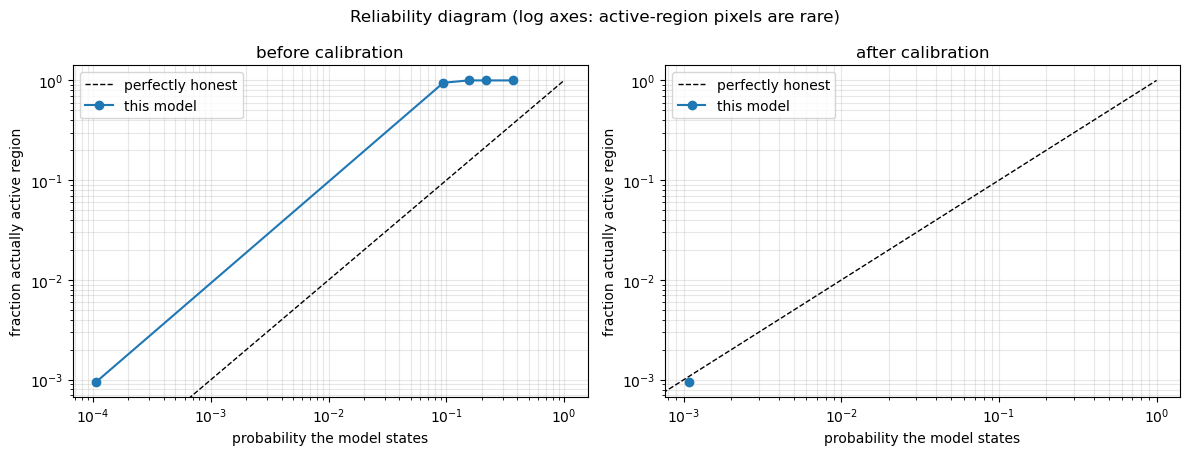

In [15]:
def reliability(hp, hn, a=1.0, b=0.0, n_bins=15):
    """Observed frequency vs stated probability, weighted by how many pixels fall in each bin."""
    p = expit(a * BIN_CENTERS + b)
    edges = np.linspace(0, 1, n_bins + 1)
    which = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    stated, observed, weight = [], [], []
    for k in range(n_bins):
        m = which == k
        tot = hp[m].sum() + hn[m].sum()
        if tot < 1:
            continue
        stated.append((p[m] * (hp[m] + hn[m])).sum() / tot)   # pixel-weighted mean stated prob
        observed.append(hp[m].sum() / tot)
        weight.append(tot)
    return np.array(stated), np.array(observed), np.array(weight)


hp_ev = pred0["hist_pos"][EVAL_IDX].sum(axis=0)
hn_ev = pred0["hist_neg"][EVAL_IDX].sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (a, b, title) in zip(axes, [(1.0, 0.0, "before calibration"),
                                    (A_CAL, B_CAL, "after calibration")]):
    s, o, w = reliability(hp_ev, hn_ev, a, b)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly honest")
    ax.plot(s, o, "o-", label="this model")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("probability the model states"); ax.set_ylabel("fraction actually active region")
    ax.set_title(title); ax.grid(alpha=.3, which="both"); ax.legend()
plt.suptitle("Reliability diagram (log axes: active-region pixels are rare)")
plt.tight_layout()

s, o, w = reliability(hp_ev, hn_ev, A_CAL, B_CAL)
ece = float((w * np.abs(s - o)).sum() / w.sum())
s0, o0, w0 = reliability(hp_ev, hn_ev)
ece0 = float((w0 * np.abs(s0 - o0)).sum() / w0.sum())
print(f"average gap between stated and observed:  before {ece0:.5f}   after {ece:.5f}")

### Does calibration change the score?

Usually barely — and that is exactly what should happen.

Calibration is a monotonic rescaling: it does not change the *order* of pixels by score. Overlap
at the best threshold depends only on that order, so the best achievable score is untouched. What
moves is the score *at a fixed threshold*, because the threshold now falls in a different place
relative to the same ranking.

What calibration actually buys is **meaning**. After it, 0.75 is a statement about the world
rather than an arbitrary label — and that is the only reason the contours in Step 4 can be read
as an error bar rather than as decoration.

Both rows below are computed on the evaluation half only, so the calibration is being judged on
images it was never fitted to.

Illustration from the smoke run (8 images, so the numbers themselves mean nothing): at the
fixed cut of 0.5, IoU went from 0.0399 *uncalibrated* to 0.0008 *calibrated*. Not a bug —
the ranking of pixels is unchanged, but 0.5 now falls somewhere else on it. This is why the
threshold sweep in the next cell matters, and why a calibrated number should always be quoted
with the threshold it was measured at.


In [16]:
# Does calibration change the score? Usually barely -- the ranking of pixels is unchanged,
# so the best achievable overlap is the same. What changes is that the threshold now means
# something, and the contours in Step 4 become interpretable.
tp_e, fp_e, fn_e = counts_at(pred0["hist_pos"][EVAL_IDX], pred0["hist_neg"][EVAL_IDX],
                             cfg.data.ar_threshold)
tp_c, fp_c, fn_c = counts_at(pred0["hist_pos"][EVAL_IDX], pred0["hist_neg"][EVAL_IDX],
                             cfg.data.ar_threshold, a=A_CAL, b=B_CAL)
print("evaluation half, at the configured threshold:")
_ = report("  uncalibrated", tp_e, fp_e, fn_e)
_ = report("  calibrated  ", tp_c, fp_c, fn_c)

evaluation half, at the configured threshold:
  uncalibrated
   pooled IoU     0.0000   95% CI [0.0000, 0.0000]   width 0.0000
   per-image IoU  0.0000   95% CI [0.0000, 0.0000]   width 0.0000
  calibrated  
   pooled IoU     0.0000   95% CI [0.0000, 0.0000]   width 0.0000
   per-image IoU  0.0000   95% CI [0.0000, 0.0000]   width 0.0000


### Where should the threshold actually sit?

The config cuts at 0.5, which is the natural choice only when the two classes are balanced. Here
they run about eighty to one, so the overlap-maximising cut usually sits well below 0.5.

The sweep recomputes overlap at 49 thresholds essentially instantly, because it is all partial
sums over the stored histograms rather than 49 fresh passes over the data. This is the payoff of
the caching design.

**A leak warning, which the cell also prints:** choosing the threshold on the same images you
then report it on inflates the result. For a number you intend to publish, pick the threshold on
the calibration half and report it on the evaluation half. The notebook shows the sweep on the
evaluation half for illustration; do not lift `BEST_T` straight into a paper.

| activity | which images |
|---|---|
| choosing the threshold | the **calibration** half |
| reporting the score at that threshold | the **evaluation** half |

The sweep below runs on the evaluation half for illustration. Do not lift `BEST_T` straight
into a paper.


configured threshold 0.5 -> IoU 0.0000
best threshold       0.02 -> IoU 0.0000

Note: choosing the threshold on the same half you report is a leak. For a headline
number, pick it on the calibration half and report it on the evaluation half.


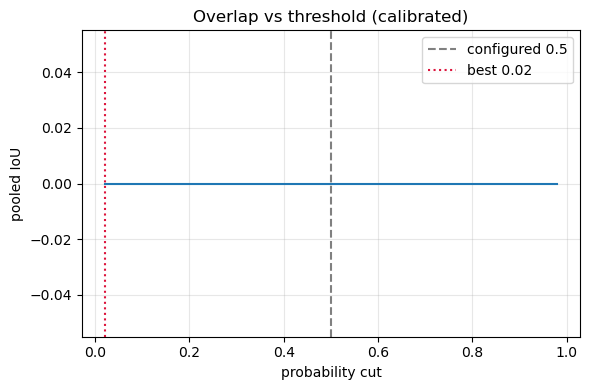

In [17]:
# The threshold that actually maximises overlap is rarely 0.5 under this much imbalance.
grid = np.linspace(0.02, 0.98, 49)
sweep = []
for t in grid:
    a_, b_, c_ = counts_at(pred0["hist_pos"][EVAL_IDX], pred0["hist_neg"][EVAL_IDX], t, A_CAL, B_CAL)
    sweep.append(pooled_iou(a_, b_, c_))
sweep = np.array(sweep)
BEST_T = float(grid[sweep.argmax()])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(grid, sweep, "-")
ax.axvline(cfg.data.ar_threshold, color="grey", ls="--", label=f"configured {cfg.data.ar_threshold}")
ax.axvline(BEST_T, color="crimson", ls=":", label=f"best {BEST_T:.2f}")
ax.set_xlabel("probability cut"); ax.set_ylabel("pooled IoU")
ax.set_title("Overlap vs threshold (calibrated)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
print(f"configured threshold {cfg.data.ar_threshold} -> IoU {sweep[np.abs(grid-cfg.data.ar_threshold).argmin()]:.4f}")
print(f"best threshold       {BEST_T:.2f} -> IoU {sweep.max():.4f}")
print("\nNote: choosing the threshold on the same half you report is a leak. For a headline")
print("number, pick it on the calibration half and report it on the evaluation half.")

---
# Step 4 — Confidence contours

The model does not output an outline. It outputs a continuous confidence surface, and
Notebooks 1 and 2 throw that away by cutting it at 0.5.

Instead, draw the boundary at **several** confidence levels at once. Where the curves sit on
top of one another, the model is decisive. Where they spread into a band, it is hedging — and
that band is the error bar on the outline.

Two honest constraints on reading these figures:

- The contours are only meaningful **because Step 3 calibrated the probabilities**. On raw
  scores the levels are arbitrary labels.
- The head is linear within each 16-pixel tile, so contour position is not meaningful below
  about 16 pixels. That is an architectural floor, not a data problem. The figures downsample
  by 4 for display, which stays well inside it.

| level | reading |
|---|---|
| 0.25 | the outer edge: "at least a one-in-four chance this is active region" |
| 0.50 | the outline that is scored |
| 0.75 | the core: "three-in-four" |

Where the three curves coincide, the model is decisive; the band between 0.25 and 0.75 is
its stated uncertainty on the outline.

**Why 16 pixels is the floor.** The image is 4096 pixels across and the model works on
16 × 16 tiles, so the head produces 256 × 256 tile-level decisions and spreads each one
linearly across its tile. Nothing finer than a tile is expressed. The figures downsample by 4
for display (1024 × 1024), which stays well inside that.

| panel | shows |
|---|---|
| 1 | calibrated confidence map |
| 2 | contours at the three levels, true outline in cyan |
| 3 | the uncertainty band (between 0.25 and 0.75) |
| 4 (ensemble only) | where the members disagree |


2011-01-16T00:00:00: uncertainty band covers 0.0000% of the frame


2011-01-16T01:00:00: uncertainty band covers 0.0000% of the frame


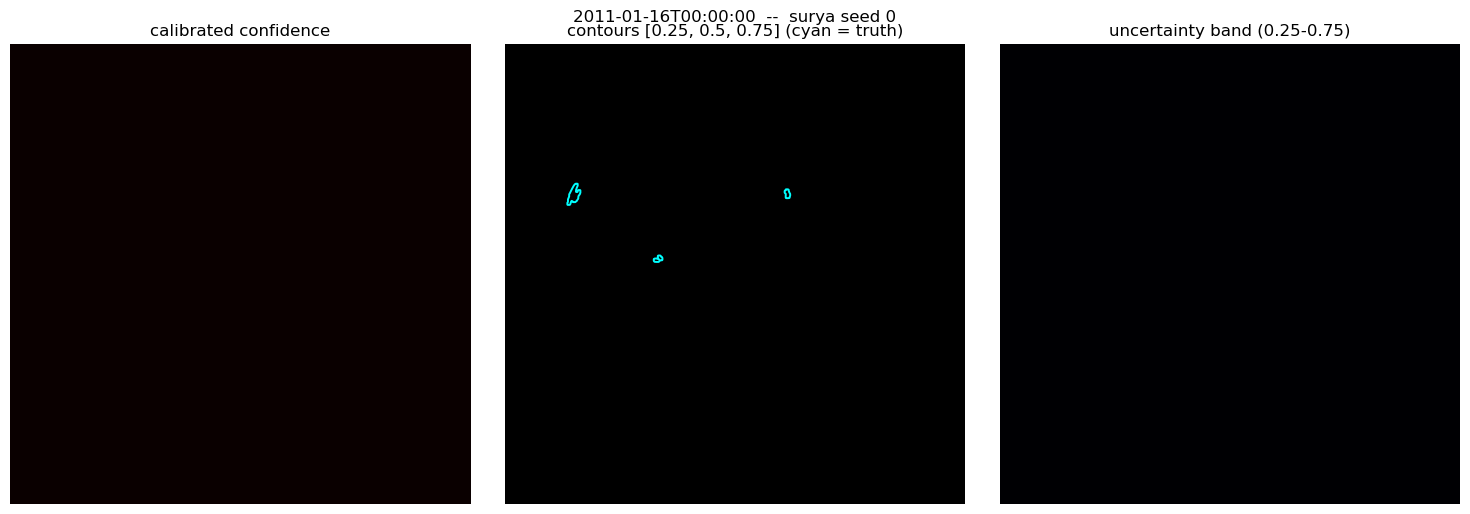

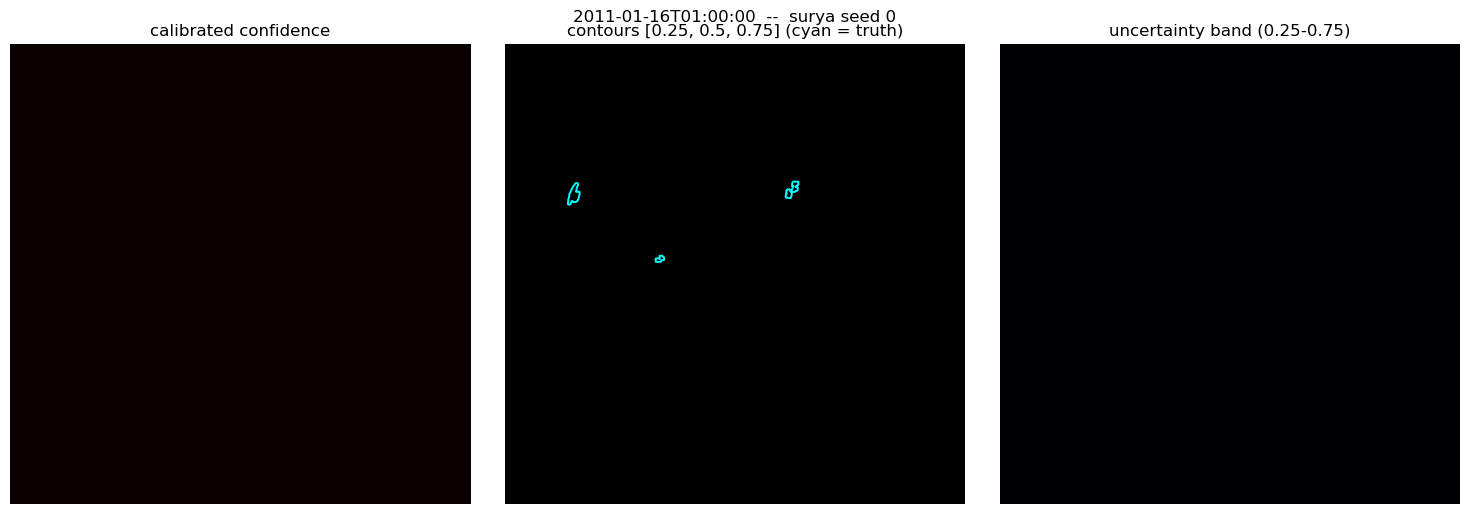

In [18]:
LEVELS = [0.25, 0.50, 0.75]
DOWN   = 4   # display downsample; 4 px << the 16 px tile floor, so nothing real is lost


def block_mean(a, f):
    h, w = a.shape
    a = a[: h - h % f, : w - w % f]
    return a.reshape(h // f, f, w // f, f).mean(axis=(1, 3))


def contour_figure(logit_map, truth, title, a=A_CAL, b=B_CAL, levels=LEVELS, spread=None):
    prob = expit(a * logit_map.astype(np.float32) + b)
    p_s  = block_mean(prob, DOWN)
    t_s  = block_mean(truth.astype(np.float32), DOWN)

    n = 3 if spread is None else 4
    fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 5.2))

    axes[0].imshow(p_s, cmap="hot", vmin=0, vmax=1, interpolation="nearest")
    axes[0].set_title("calibrated confidence")

    axes[1].imshow(np.zeros_like(p_s), cmap="gray", vmin=0, vmax=1)
    cs = axes[1].contour(p_s, levels=levels, cmap="autumn", linewidths=1.0)
    axes[1].contour(t_s, levels=[0.5], colors="cyan", linewidths=1.4)
    axes[1].clabel(cs, inline=True, fontsize=7, fmt="%.2f")
    axes[1].set_title(f"contours {levels} (cyan = truth)")
    axes[1].invert_yaxis()

    band = (p_s >= min(levels)).astype(float) - (p_s >= max(levels)).astype(float)
    axes[2].imshow(band, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
    axes[2].set_title(f"uncertainty band ({min(levels)}-{max(levels)})")

    if spread is not None:
        axes[3].imshow(block_mean(spread, DOWN), cmap="viridis", interpolation="nearest")
        axes[3].set_title("ensemble disagreement")

    for ax in axes:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    return band.mean()


for k in range(len(pred0["maps"])):
    frac = contour_figure(pred0["maps"][k], pred0["truths"][k],
                          f"{pred0['index'][k]}  --  {MODEL_KIND} seed 0")
    print(f"{pred0['index'][k]}: uncertainty band covers {frac:.4%} of the frame")

---
# Step 5 — An ensemble of adapter seeds

One trained model gives one answer. Train it again from a different random start and the
answer shifts slightly. That shift is real uncertainty, and a single run is blind to it.

This is unusually cheap here. The default regime freezes the 366-million-parameter backbone
and trains only the small adapters, so several members cost a fraction of several full
fine-tunes.

Two products:

- the **average** confidence map, which is a better prediction than any single member;
- the **spread** between members at each pixel, which is a genuine uncertainty map. Expect it
  to light up along region *boundaries*: the members agree that a region is there and disagree
  about exactly where it ends.

| what is shared | what differs per member |
|---|---|
| the 366 M-parameter backbone, frozen | ≈ 3 M adapter-and-head parameters, from a different random seed |

| product | how it is made | what it tells you |
|---|---|---|
| **mean** map | average of the members' calibrated probabilities | a better prediction than any single member |
| **spread** map | standard deviation across members, per pixel | genuine uncertainty; lights up along region boundaries |

Members are combined in probability space using member 0's calibration. A fussier treatment
fits one calibration per member; with few images that overfits.


2 members | mean pixel spread 0.00006 | max 0.0003


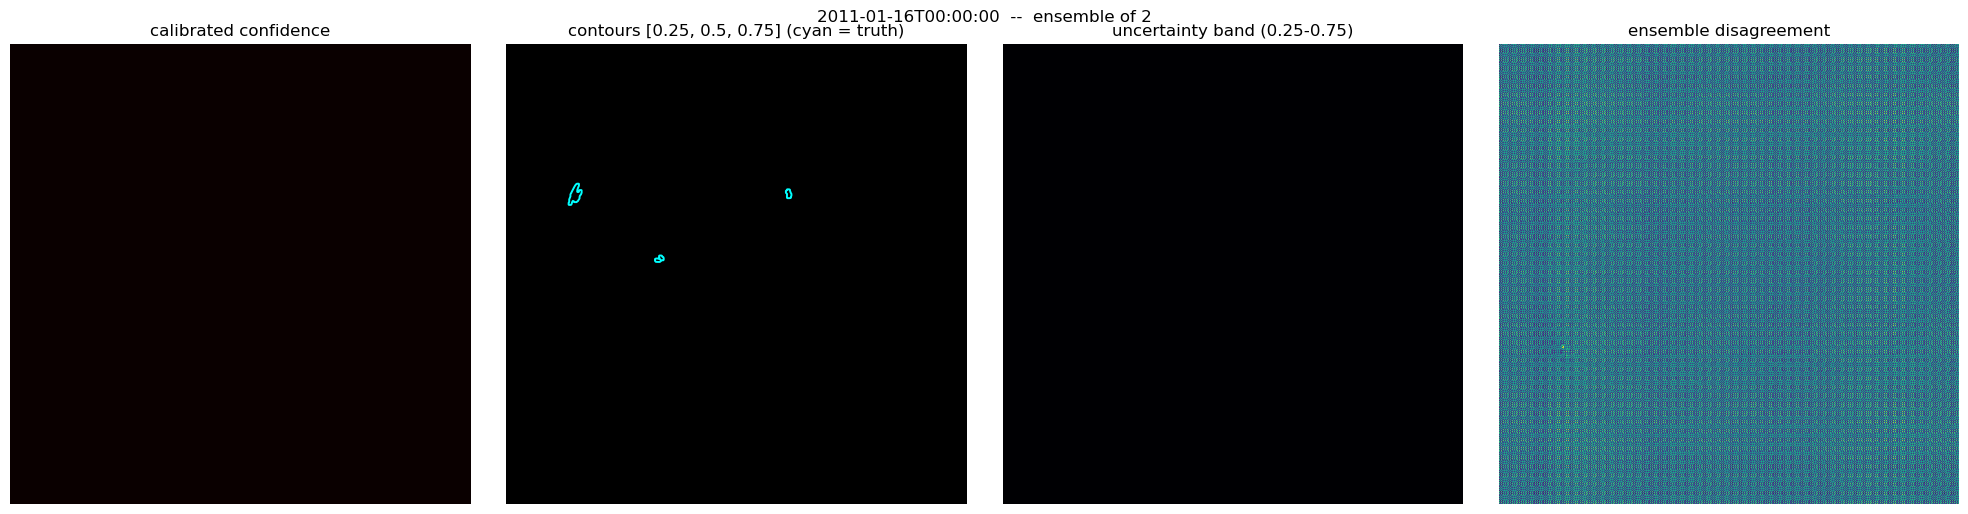

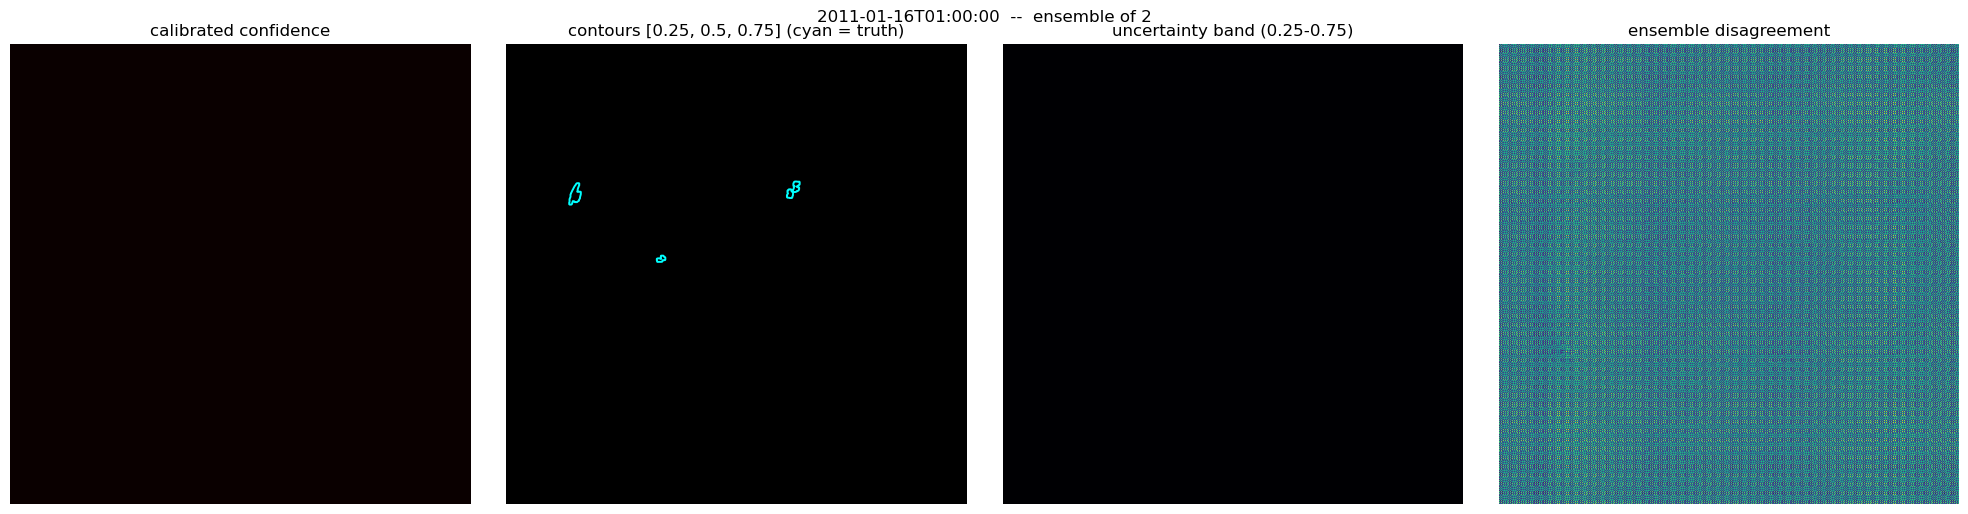

In [19]:
if len(members) < 2:
    print("Only one member trained. Raise n_seeds in the budget cell to run this step.")
    ens = None
else:
    per_member = [pred0] + [collect(m, val_loader, keep_maps=P["contour_images"])
                            for m in members[1:]]

    # Average in probability space, using the calibration fitted on member 0.
    # A fussier treatment fits one calibration per member; with few images that overfits.
    probs = [expit(A_CAL * np.stack([mp.astype(np.float32) for mp in pm["maps"]]) + B_CAL)
             for pm in per_member]
    probs = np.stack(probs)                    # (members, images, H, W)
    mean_p   = probs.mean(axis=0)
    spread_p = probs.std(axis=0)

    print(f"{len(members)} members | mean pixel spread {spread_p.mean():.5f} | "
          f"max {spread_p.max():.4f}")

    for k in range(mean_p.shape[0]):
        z_mean = _logit(np.clip(mean_p[k], 1e-6, 1 - 1e-6))
        contour_figure(z_mean.astype(np.float16), per_member[0]["truths"][k],
                       f"{per_member[0]['index'][k]}  --  ensemble of {len(members)}",
                       a=1.0, b=0.0, spread=spread_p[k])

    ens = dict(per_member=per_member, mean_p=mean_p, spread_p=spread_p)

### Scoring each member on the same footing

Every member is scored at the same threshold, under the same calibration, and each gets its own
bootstrap interval.

**The comparison that matters is the final two printed lines.** If the spread of the score across
seeds is comparable to the width of a single seed's bootstrap interval, then two things are true
at once:

- a single run's number is not reproducible to the precision you were about to quote it at; and
- model-to-model variation is as large as the measurement noise on any one model.

In that situation, quoting three decimals from one training run is indefensible, and the right
report is the ensemble mean with a spread attached.

| seed-to-seed spread of the score | vs one seed's bootstrap width | conclusion |
|---|---|---|
| much smaller | | training randomness is negligible; sampling dominates |
| comparable | | a single run's number is not reproducible to the precision you were about to quote; report the ensemble mean with a spread |
| much larger | | training is unstable; look at the trajectory before trusting any of it |


In [20]:
if ens is not None:
    # Score each member and the ensemble on the same footing.
    rows = []
    for s, pm in zip(SEEDS, ens["per_member"]):
        a_, b_, c_ = counts_at(pm["hist_pos"], pm["hist_neg"], cfg.data.ar_threshold, A_CAL, B_CAL)
        lo, md_, hi = bootstrap(a_, b_, c_, mode="pooled")
        rows.append(dict(model=f"seed {s}", iou=pooled_iou(a_, b_, c_), lo=lo, hi=hi))

    spread_between = np.std([r["iou"] for r in rows])
    df_ens = pd.DataFrame(rows)
    print(df_ens.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print(f"\nspread of the score across seeds: {spread_between:.4f}")
    print(f"width of one seed's bootstrap interval: {rows[0]['hi']-rows[0]['lo']:.4f}")
    print("\nIf the seed-to-seed spread is comparable to the bootstrap width, then reporting a")
    print("single run's number to three decimals is not defensible.")

 model    iou     lo     hi
seed 0 0.0000 0.0000 0.0000
seed 1 0.0000 0.0000 0.0000

spread of the score across seeds: 0.0000
width of one seed's bootstrap interval: 0.0000

If the seed-to-seed spread is comparable to the bootstrap width, then reporting a
single run's number to three decimals is not defensible.


---
# Step 6 — The label floor

This is the step that changes how everything above is read.

The outlines are not ground truth. They are the output of a fixed rule applied to the magnetic
map: threshold at ±50 gauss, drop blobs under 100 pixels, grow the edges by 10 pixels, keep
only regions containing a polarity inversion line. **Nobody in the Sun decided on 50 gauss.**

So: re-run that rule at ±40 and ±60 gauss and see how far the "truth" moves. Two equally
defensible answer keys that disagree with each other by some amount set a floor — no model
scored against one of them can be meaningfully resolved below it.

### Validate the reconstruction first

The code below is a reconstruction of the published recipe from its documented parameters, not
the original authors' code. **It is only trustworthy where it reproduces the shipped outlines**,
so the first thing it does is score itself at 50 gauss against the real answer key.

The rule is now known from the published description (Roy et al. 2026, *Scientific Data*
13:712): size filter before dilation, and a "rectangular filter of size 10 pixels", which
measurement shows means a square brush grown 10 px rather than a disc. Against the released
outlines on well-behaved days (2011-01-16) the reconstruction reaches IoU 0.66–0.92 for the
footprints and 0.72–0.85 for the PILs; on the first days of the mission (2010-05-13) it fails
(IoU under 0.2). Those 2010 months were absent from the preprint version of the dataset, so the
magnetograms served here for 2010 may not be the ones the rule was run on. The residual gap on
good days most likely comes from how an "AR containing a PIL" is delimited, which the paper does
not specify. Full validation in `GROUND_TRUTH_EXPLAINED.md`.

**Read the agreement column before you read the floor.** Where agreement is low, the floor
estimate on that image means nothing.

### Where the answer key comes from

The outlines are the **ARPIL** task of SuryaBench — Roy *et al.*, *Scientific Data* 13, 712
(2026), https://doi.org/10.1038/s41597-026-06552-5 — produced from **SDO/HMI line-of-sight
magnetograms** (4096 × 4096, about 0.36 Mm per pixel at disk centre) by a fixed rule, applied
once per hour. Quotations below are from the paper.

```mermaid
flowchart TD
    M["HMI line-of-sight magnetogram<br/>field in gauss, sign = polarity"] --> T1["threshold  B > +50 G"]
    M --> T2["threshold  B < −50 G"]
    T1 --> S1["drop regions < 100 px<br/>(≈ 13.3 Mm²)"]
    T2 --> S2["drop regions < 100 px"]
    S1 --> D1["dilate: square brush, 10 px"]
    S2 --> D2["dilate: square brush, 10 px"]
    D1 --> I["intersection<br/>= polarity inversion lines"]
    D2 --> I
    D1 --> U["union of the two"]
    D2 --> U
    I --> K["keep union blobs<br/>that contain a PIL"]
    U --> K
    I --> O1[("intersection<br/>0 / 1")]
    K --> O2[("union_with_intersect<br/>0 / 255")]
```

| step | the paper says | effect |
|---|---|---|
| 1 threshold | "magnetic field strength threshold of +50 and −50 Gauss" | two black-and-white maps, one per polarity; quiet Sun off in both |
| 2 size filter | "excludes regions smaller than 100 pixels (approximately 13.3 Mm²)" — **before** dilation | noise and small elements removed |
| 3 dilation | "a rectangular filter of size 10 pixels" | every patch grown 10 px; opposite polarities within ~20 px now overlap |
| 4 intersection | "the intersection of the dilated positive and negative polarity regions ... contains PILs" | the **PIL map** — where field toward us meets field away |
| 5 selection | "Only ARs that include PILs are reported" | strong **unipolar** patches are dropped on purpose |
| 6 output | "2D bitmaps ... 4096 × 4096" | two maps per hour |

### What is in each hourly file

| key | holds | stored as |
|---|---|---|
| `intersection` | the PIL map | 0 / **1** |
| `union_with_intersect` | active-region footprints containing a PIL — the default target | 0 / **255** |

The PIL map is a strict subset of the footprint map. The files carry no record of the
parameters; the rule is known from the paper.

| catalogue | covers |
|---|---|
| `train.csv` | 15 Feb – 31 Dec, 2010–2019 |
| `validation.csv` | 15 – 31 Jan, 2010–2019 |
| `leaky_validation.csv` | 1 – 14 Jan and 1 – 14 Feb, 2010–2019 |
| `test.csv` | 2020 – 2024 |

128,352 hourly rows, **121,963 with a mask** (matches the published count; the preprint's
119,454 excluded 2010).

### Why the rule insists on a dividing line

A polarity inversion line is where opposite polarities meet — where field is sheared and
twisted, where energy is stored, and where flares are launched. A large patch of strong field
of a **single** sign is magnetically quiet, and the rule leaves it out. When a model later flags
such a patch it has not necessarily erred in perception; it has disagreed with a definition.
This is the most common source of apparent false positives.


In [21]:
from skimage.morphology import remove_small_objects
from scipy import ndimage as ndi

MIN_SIZE = 100    # documented: blobs smaller than this are dropped
RADIUS   = 10     # documented: "rectangular filter of size 10 pixels" (Roy et al. 2026)
THRESHOLDS = [40.0, 50.0, 60.0]
RECIPE_MIN_AGREEMENT = 0.60   # below this, the reconstruction is not reproducing the product


def ar_recipe(B, thr=50.0, min_size=MIN_SIZE, radius=RADIUS):
    """Reconstruct (active-region footprints, polarity inversion lines) from a magnetogram.

    Follows Roy et al. 2026 (SuryaBench, Sci. Data 13:712): +/-50 G thresholds, size
    filter BEFORE dilation, "rectangular filter of size 10 pixels" (a square brush grown
    10 px -- measured to beat a disc on 12/12 timestamps for the PIL map), intersection
    for the PILs, union blobs containing a PIL for the footprints. See
    GROUND_TRUTH_EXPLAINED.md for the validation and the residual uncertainties.
    """
    pos = remove_small_objects(B >  thr, min_size)
    neg = remove_small_objects(B < -thr, min_size)
    brush = np.ones((3, 3), bool)                # square, 8-connected
    pos_d = ndi.binary_dilation(pos, structure=brush, iterations=radius)
    neg_d = ndi.binary_dilation(neg, structure=brush, iterations=radius)
    pil   = pos_d & neg_d                       # the "intersection" key
    lab, _ = ndi.label(pos_d | neg_d)
    keep = np.unique(lab[pil]); keep = keep[keep > 0]
    return np.isin(lab, keep), pil              # the "union_with_intersect" key


def iou_bool(a, b):
    u = (a | b).sum()
    return 1.0 if u == 0 else float((a & b).sum() / u)


HMI_IDX = cfg.data.channels.index("hmi_m")
print(f"hmi_m is channel {HMI_IDX} of {len(cfg.data.channels)}")

hmi_m is channel 8 of 13


### Re-deriving the answer key at three thresholds

For each validation image this recovers the magnetogram in physical units — by running the
normalization backwards — and then re-runs the marking rule at 40, 50 and 60 gauss.

This needs no model at all; it is pure image processing. It is also the **slowest cell in the
notebook**: growing the blob edges across a 4096x4096 map takes a few seconds per image per
threshold, so twelve images means a few minutes.

Four numbers come back per image, and they are not equally important:

| Column | Meaning |
|---|---|
| `agreement_50` | How well the reconstruction reproduces the **shipped** answer key. The trust check — read this first. |
| `iou_40_vs_60` | How far apart two equally defensible answer keys are. **This is the floor.** |
| `iou_40_vs_shipped` | The same wobble, measured against the key the model was trained on. |
| `iou_60_vs_shipped` | As above, in the other direction. |

The magnetogram is recovered with `inverse_transform_data()` — the *physical* space in the
table under "Fetch the weights" above — so the thresholds are genuinely in gauss. Budget a few
seconds per image per threshold for the morphology on a 4096 × 4096 map.


In [22]:
val_ds = val_loader.dataset
n_floor = min(len(val_ds), 12 if BUDGET == "smoke" else 60)
print(f"re-deriving the answer key for {n_floor} validation images "
      f"(a few seconds each at 4096x4096)\n")

floor_rows = []
for i in range(n_floor):
    item = val_ds[i]
    physical = val_ds.inverse_transform_data(item["ts"][:, 0, ...])    # -> DN and Gauss
    B = np.nan_to_num(np.asarray(physical[HMI_IDX], dtype=np.float32))
    shipped = np.asarray(item["forecast"]) > 0.5

    variants = {t: ar_recipe(B, thr=t)[0] for t in THRESHOLDS}
    row = dict(
        ds_index=item["ds_index"],
        B_absmax=float(np.abs(B).max()),
        shipped_frac=float(shipped.mean()),
        agreement_50=iou_bool(variants[50.0], shipped),
        iou_40_vs_60=iou_bool(variants[40.0], variants[60.0]),
        iou_40_vs_shipped=iou_bool(variants[40.0], shipped),
        iou_60_vs_shipped=iou_bool(variants[60.0], shipped),
    )
    floor_rows.append(row)
    print(f"{row['ds_index']}  |B|max {row['B_absmax']:7.1f} G  shipped {row['shipped_frac']:.5f}  "
          f"agreement@50 {row['agreement_50']:.3f}  40v60 {row['iou_40_vs_60']:.3f}")

df_floor = pd.DataFrame(floor_rows)

re-deriving the answer key for 8 validation images (a few seconds each at 4096x4096)



2011-01-16T00:00:00  |B|max   884.0 G  shipped 0.00101  agreement@50 0.718  40v60 0.453


2011-01-16T01:00:00  |B|max   907.9 G  shipped 0.00128  agreement@50 0.688  40v60 0.582


2011-01-16T02:00:00  |B|max   919.8 G  shipped 0.00099  agreement@50 0.875  40v60 0.840


2011-01-16T03:00:00  |B|max   925.3 G  shipped 0.00102  agreement@50 0.756  40v60 0.871


2011-01-16T04:00:00  |B|max   956.8 G  shipped 0.00105  agreement@50 0.583  40v60 0.561


2011-01-16T05:00:00  |B|max   990.6 G  shipped 0.00091  agreement@50 0.894  40v60 0.834


2011-01-16T06:00:00  |B|max  1009.7 G  shipped 0.00092  agreement@50 0.893  40v60 0.672


2011-01-16T07:00:00  |B|max  1037.7 G  shipped 0.00092  agreement@50 0.763  40v60 0.569


### Trust the reconstruction before trusting the floor

The recipe implemented above was reconstructed from documented parameters, not lifted from the
original authors' code. It is therefore only evidence **where it reproduces their published
product**.

The rule is now known from the published description (Roy et al. 2026, *Scientific Data*
13:712): size filter before dilation, and a "rectangular filter of size 10 pixels", which
measurement shows means a square brush grown 10 px rather than a disc. Against the released
outlines on well-behaved days (2011-01-16) the reconstruction reaches IoU 0.66–0.92 for the
footprints and 0.72–0.85 for the PILs; on the first days of the mission (2010-05-13) it fails
(IoU under 0.2). Those 2010 months were absent from the preprint version of the dataset, so the
magnetograms served here for 2010 may not be the ones the rule was run on. The residual gap on
good days most likely comes from how an "AR containing a PIL" is delimited, which the paper does
not specify. Full validation in `GROUND_TRUTH_EXPLAINED.md`.

This cell therefore computes the floor **only from images clearing `RECIPE_MIN_AGREEMENT`**, and
prints `NOT ESTABLISHED` rather than inventing a number if none of them do. A floor computed from
images where the reconstruction disagrees with the real answer key would be measuring the
reconstruction's own failure, not the definition's ambiguity — which is precisely the mistake
this whole notebook exists to avoid.

### How faithfully the rule reproduces (measured)

| finding | evidence |
|---|---|
| size filter must come **before** dilation | reversed, agreement collapses to IoU 0.01–0.09 |
| "rectangular filter of size 10" = a **square brush grown 10 px**, not a disc, not a 10 × 10 box | on 12 timestamps: PIL agreement better on 12/12 (median 0.74 → 0.80); footprint agreement better on 9/12 (≈ 0.85 → 0.86); a 10 × 10 box scores 0.70 |
| well-behaved days reproduce closely | 2011-01-16: footprints 0.66–0.92, PILs 0.72–0.85 |
| the first days of the mission do not | 2010-05-13: footprints ≈ 0.0–0.18 |

**What explains the remaining gap** (≈ 0.85 rather than 1.0 on good days) is not settled.
Leading candidate: the paper never defines what counts as one "AR" for the contains-a-PIL
test; the reconstruction uses a connected component of the union, and the three timestamps
where the square brush scored *worse* moved by 0.1–0.2 at once — whole blobs flipping, not
edges shifting. Smaller candidates: brush semantics, treatment of the disk edge, the version
of the magnetogram data.

None of this affects training; it bounds how finely the floor can be read, which is why the
floor is computed only from images clearing `RECIPE_MIN_AGREEMENT`.


In [23]:
ok = df_floor["agreement_50"] >= RECIPE_MIN_AGREEMENT
print(f"reconstruction reproduces the shipped answer key on "
      f"{ok.sum()} / {len(df_floor)} images (IoU >= {RECIPE_MIN_AGREEMENT})")
print(f"median agreement at 50 G: {df_floor['agreement_50'].median():.3f}\n")

if ok.sum() == 0:
    LABEL_FLOOR = None
    print("*** The reconstruction does not reproduce the published outlines on ANY image here.")
    print("*** Do not interpret a label floor from this run. Likely causes: early-mission data,")
    print("*** a quiet Sun where regions are tiny, or an undocumented step in the original recipe.")
else:
    trusted = df_floor[ok]
    LABEL_FLOOR = float(trusted["iou_40_vs_60"].median())
    print(f"On the {len(trusted)} images where the reconstruction is trustworthy:")
    print(f"   median IoU between the +/-40 G and +/-60 G answer keys : {LABEL_FLOOR:.4f}")
    print(f"   median IoU  40 G vs the shipped 50 G key               : {trusted['iou_40_vs_shipped'].median():.4f}")
    print(f"   median IoU  60 G vs the shipped 50 G key               : {trusted['iou_60_vs_shipped'].median():.4f}")
    print()
    print("Read this as: two equally defensible versions of the answer key agree with each")
    print(f"other only to IoU {LABEL_FLOOR:.3f}. A model scored against one of them cannot be")
    print("meaningfully resolved any finer than that.")

print()
print(df_floor.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

reconstruction reproduces the shipped answer key on 7 / 8 images (IoU >= 0.6)
median agreement at 50 G: 0.759

On the 7 images where the reconstruction is trustworthy:
   median IoU between the +/-40 G and +/-60 G answer keys : 0.6720
   median IoU  40 G vs the shipped 50 G key               : 0.7860
   median IoU  60 G vs the shipped 50 G key               : 0.8364

Read this as: two equally defensible versions of the answer key agree with each
other only to IoU 0.672. A model scored against one of them cannot be
meaningfully resolved any finer than that.

           ds_index  B_absmax  shipped_frac  agreement_50  iou_40_vs_60  iou_40_vs_shipped  iou_60_vs_shipped
2011-01-16T00:00:00  884.0234        0.0010        0.7181        0.4534             0.4592             0.6741
2011-01-16T01:00:00  907.9268        0.0013        0.6880        0.5821             0.7946             0.6426
2011-01-16T02:00:00  919.8361        0.0010        0.8750        0.8398             0.8633             0.8

### Seeing the answer key wobble

Every coloured curve in this figure is "the truth". They differ only in a threshold that nobody
can justify to three digits, drawn here over the magnetogram they were all derived from. The
dashed white curve is the answer key actually shipped with the dataset.

**The gap between the cyan and red curves is the width of the target.** Where a model's
disagreement with the shipped key is smaller than that gap, the disagreement is not evidence of
anything about the model — it is evidence that the question was not asked precisely enough.

This single figure is usually the most persuasive thing in the notebook when explaining to a
non-specialist why a segmentation score cannot be quoted to three decimals.

### Limitations of the rule itself

| limitation | consequence |
|---|---|
| threshold is on the **line-of-sight** field | near the limb the field is seen side-on and its measured component shrinks; regions there are under-detected and drawn smaller |
| sizes are in **pixels**, not kilometres | 100 px and 10 px cover far more solar surface near the foreshortened limb than at disk centre |
| 50 G, 100 px, 10 px are **choices** | nudging any of them moves every outline — the floor this step measures |
| the answer key is derived from one of the model's **inputs** (`hmi_m`) | a model can imitate the rule from that channel alone; Notebook 1's two-parameter baseline measures how much of the task the rule already explains |
| hourly only | four of five images have no outline |


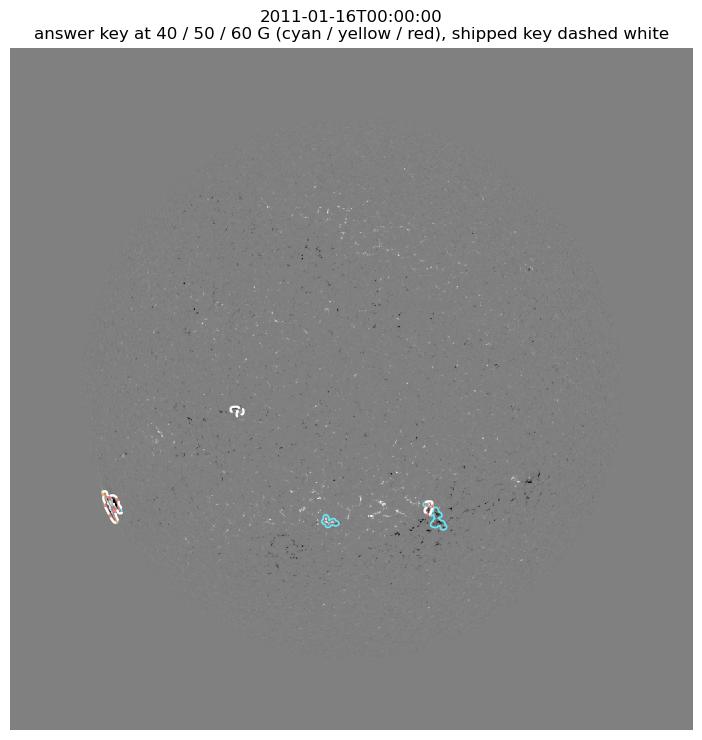

In [24]:
# Look at the answer key wobbling. The three curves are all "the truth".
if len(pred0["maps"]) > 0 and n_floor > 0:
    item = val_ds[0]
    B = np.nan_to_num(np.asarray(
        val_ds.inverse_transform_data(item["ts"][:, 0, ...])[HMI_IDX], dtype=np.float32))
    shipped = np.asarray(item["forecast"]) > 0.5

    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    ax.imshow(block_mean(np.clip(B, -300, 300), DOWN), cmap="gray", interpolation="nearest")
    for t, col in zip(THRESHOLDS, ["#67e8f9", "#facc15", "#fb7185"]):
        m, _ = ar_recipe(B, thr=t)
        ax.contour(block_mean(m.astype(np.float32), DOWN), levels=[0.5], colors=[col], linewidths=1.2)
    ax.contour(block_mean(shipped.astype(np.float32), DOWN), levels=[0.5],
               colors="white", linewidths=1.6, linestyles="--")
    ax.set_title(f"{item['ds_index']}\nanswer key at 40 / 50 / 60 G (cyan / yellow / red), "
                 f"shipped key dashed white")
    ax.axis("off")
    plt.tight_layout()

---
# Putting it together

Every score, with its interval, against the floor set by the answer key itself.

The question this table answers is not "what did the model score". It is **"is the gap between
these numbers larger than the uncertainty in measuring them, and larger than the ambiguity in
the definition they are measured against?"**

| best model score vs the floor | reading |
|---|---|
| below the floor | model error dominates definitional ambiguity: real headroom |
| at or above the floor | the model agrees with the key about as well as two defensible keys agree with each other; further gains on this metric are not distinguishable from a different threshold in the rule |
| floor `NOT ESTABLISHED` | the reconstruction did not validate on these images; do not interpret a floor from this run |

### What a healthy trajectory looked like

The first run of this notebook collapsed; the numbers below are the record, and the reason
every knob above exists.

| run | epoch | IoU | precision | recall | what happened |
|---|---|---|---|---|---|
| smoke, original | 0 | 0.0054 | 0.71 | 0.0054 | |
| smoke, original | 1 | **0.000035** | 1.00 | 0.000035 | loss improved; the model stopped predicting anything |
| smoke, fixed | 1 | 0.041 | 0.40 | 0.043 | off the floor; still an 8-image, 2-pass model |
| medium, seed 0 | 0 | 0.435 | 0.52 | 0.73 | a real segmentation from the first pass; `dice` term 0.98 → 0.23 |
| medium, seed 0 | 1 (best) | 0.431 | 0.48 | 0.79 | lowest `val_loss`; IoU stays ~0.43 for all ten epochs while `val_loss` rises — 60 images overfit after one pass |

Three causes, all now handled by the cells above: the images were January 2011 (0.1 %
coverage), the rare pixels were not up-weighted, and the foundation model was training at ten
times its recommended rate.

### Final results at `medium` (best-epoch weights, random calibration split)

| quantity | value |
|---|---|
| seed 0, IoU at 0.5, pooled over 60 validation images | **0.437**, 95 % CI [0.424, 0.449] |
| calibration | *a* = 0.46, *b* = −1.98; stated-vs-observed gap 0.0098 → **0.0015** |
| evaluation half, uncalibrated → calibrated at 0.5 | 0.444 → 0.444 (the random split removed the 0.10 gap the index split had) |
| best threshold on the calibrated map | 0.28 → IoU **0.465** |
| seed 0 / seed 1 at that threshold | 0.459 / 0.417 |
| seed-to-seed spread vs one seed's bootstrap width | **0.025 vs 0.021** — comparable, so a single run is not quotable to three decimals; report the pair |
| reconstruction agreement with the answer key | 60/60 images ≥ 0.6, median 0.81 |
| **label floor** (±40 G vs ±60 G keys agree to) | **0.632** |
| verdict | best model 0.459 < floor 0.632: model error dominates definitional ambiguity — real headroom |


In [25]:
summary = []

tp_f, fp_f, fn_f = counts_at(pred0["hist_pos"], pred0["hist_neg"], cfg.data.ar_threshold)
lo, md_, hi = bootstrap(tp_f, fp_f, fn_f, mode="pooled")
summary.append(dict(what=f"{MODEL_KIND} seed 0, uncalibrated",
                    iou=pooled_iou(tp_f, fp_f, fn_f), lo=lo, hi=hi))

tp_f, fp_f, fn_f = counts_at(pred0["hist_pos"], pred0["hist_neg"], BEST_T, A_CAL, B_CAL)
lo, md_, hi = bootstrap(tp_f, fp_f, fn_f, mode="pooled")
summary.append(dict(what=f"{MODEL_KIND} seed 0, calibrated @ {BEST_T:.2f}",
                    iou=pooled_iou(tp_f, fp_f, fn_f), lo=lo, hi=hi))

if ens is not None:
    for s, pm in zip(SEEDS, ens["per_member"]):
        a_, b_, c_ = counts_at(pm["hist_pos"], pm["hist_neg"], BEST_T, A_CAL, B_CAL)
        lo, md_, hi = bootstrap(a_, b_, c_, mode="pooled")
        summary.append(dict(what=f"  member seed {s}", iou=pooled_iou(a_, b_, c_), lo=lo, hi=hi))

df_sum = pd.DataFrame(summary)
df_sum["CI_width"] = df_sum.hi - df_sum.lo
print(df_sum.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print()
if LABEL_FLOOR is not None:
    print(f"label floor (40 G vs 60 G answer keys agree to) : {LABEL_FLOOR:.4f}")
    best = df_sum.iou.max()
    if best < LABEL_FLOOR:
        print(f"\nThe best model scores {best:.3f}, below the floor of {LABEL_FLOOR:.3f}.")
        print("Model error dominates definitional ambiguity: there is real headroom here.")
    else:
        print(f"\nThe best model scores {best:.3f}, at or above the floor of {LABEL_FLOOR:.3f}.")
        print("The model now agrees with the answer key about as well as two equally defensible")
        print("answer keys agree with each other. Further gains on this metric are not")
        print("distinguishable from a different choice of threshold in the labelling rule.")
else:
    print("label floor: NOT ESTABLISHED (see Step 6 -- the reconstruction did not validate)")

print()
print(f"budget = {BUDGET}")
if BUDGET == "smoke":
    print("*** These are smoke-test numbers. Nothing above should be reported. ***")

                           what    iou     lo     hi  CI_width
     surya seed 0, uncalibrated 0.0000 0.0000 0.0001    0.0001
surya seed 0, calibrated @ 0.02 0.0000 0.0000 0.0000    0.0000
                  member seed 0 0.0000 0.0000 0.0000    0.0000
                  member seed 1 0.0000 0.0000 0.0000    0.0000

label floor (40 G vs 60 G answer keys agree to) : 0.6720

The best model scores 0.000, below the floor of 0.672.
Model error dominates definitional ambiguity: there is real headroom here.

budget = smoke
*** These are smoke-test numbers. Nothing above should be reported. ***


---
## What to do next

- **The intervals, not the numbers, are the result.** If Notebook 2's Surya score and
  Notebook 1's baseline score have overlapping intervals, the honest statement is that this
  experiment did not resolve a difference — not that the two are equal.
- **Per-region scoring.** Per-pixel overlap is not what a forecaster wants. Label the connected
  blobs in the prediction and the truth, match them, and report detection rate, false alarm
  rate, and per-region position and area errors. `scipy.ndimage.label` is already imported.
- **Test-time augmentation** is the cheapest uncertainty source not used here: flip the input,
  predict, flip the prediction back, average. Note the training pipeline deliberately disables
  vertical flips because it would flip the image and not the mask — at prediction time you
  control both, so it is safe.
- **Dropout sampling needs enabling first.** Both dropout settings in the config are `0.0`, so
  sampling with dropout left on yields exactly zero spread until you change them and retrain.
- **The label floor deserves more than three thresholds.** The minimum blob size and the
  10-pixel growth are equally arbitrary. Varying those too gives a fuller picture of how much
  of the remaining error is definitional rather than the model's.

### Quick reference: the outputs, in order

| step | figure or table | the one thing to look at |
|---|---|---|
| training | precision and recall per epoch | neither near 0 or 1; `dice` moving |
| 2 | score with 95 % interval; width vs image count | interval narrower than the gap you care about |
| 3 | reliability diagram, before and after | "after" closer to the diagonal |
| 3 | overlap vs threshold | where the best cut actually sits |
| 4 | three-level contours and uncertainty band | band width along boundaries |
| 5 | ensemble mean, disagreement map, per-seed scores | seed spread vs bootstrap width |
| 6 | agreement of the reconstruction, then the floor | agreement first; floor only where it is high |
| end | every score with interval, next to the floor | is the gap bigger than both? |

### Scoring by region instead of by pixel (sketch)

```
label(prediction > t)  →  predicted blobs
label(truth)           →  true blobs
match blobs that overlap  →  detection rate, false-alarm rate
per matched pair          →  centroid offset (px), area error (%)
```

That turns "IoU 0.7" into "this region's area is 4,200 ± 600 px and its centre is uncertain
by ± 20 px" — what a forecaster can act on, and what confidence contours express naturally.

### Running inside a container

`free` and `nproc` report the whole node. The real limits are in `/sys/fs/cgroup/`
(`memory.max`, `cpu.max`); exceeding the memory one kills and restarts the whole pod. The
budget cell reads them. The kernel also charges the pod for the file cache of every `.nc` read
— that part is reclaimable and harmless (observed: ~80,000 reclaims at the limit, zero OOMs);
only anonymous + shared memory can trigger the kill, and that is what the sizing is against.
